In [2]:
from pathlib import Path
import pandas as pd

candidates = [
    Path("eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"),
    Path("../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"),
]

log_path = next(path for path in candidates if path.exists())

df = pd.read_csv(log_path)

cols = [
    "experiment_name",
    "retriever_type",
    "embedding_model",
    "reranker",
    "overall_hit_at_5",
    "overall_mrr_at_5",
    "overall_ndcg_at_5",
]

summary = df[cols].copy()
summary

,experiment_name,retriever_type,embedding_model,reranker,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5
0,01_bm25_canonical,bm25,text-embedding-3-small,False,0.576,0.565333,0.568095
1,02_dense_openai_small_canonical,dense,text-embedding-3-small,False,0.584,0.574667,0.577095
2,03_hybrid_openai_small_canonical,hybrid,text-embedding-3-small,False,0.578,0.565000,0.568357
3,04_hybrid_openai_small_rerank_canonical,hybrid,text-embedding-3-small,True,0.586,0.576333,0.578833
4,01_bm25_canonical_multi_filter_fix,bm25,text-embedding-3-small,False,0.976,0.949167,0.830159
5,02_dense_openai_small_canonical_multi_filter_fix,dense,text-embedding-3-small,False,0.976,0.950067,0.845504
6,03_hybrid_openai_small_canonical_multi_filter_fix,hybrid,text-embedding-3-small,False,0.978,0.948833,0.830016
7,04_hybrid_openai_small_rerank_canonical_multi_...,hybrid,text-embedding-3-small,True,0.986,0.964900,0.839861
8,05_bm25_rag_database_canonical,bm25,text-embedding-3-small,False,0.806,0.738733,0.652654
9,12_hybrid_rerank_soyeon_125_koe5_faiss_canonical,hybrid,nlpai-lab/KoE5,True,0.988,0.959333,0.847099


In [7]:
summary.sort_values("overall_hit_at_5", ascending=False)

,experiment_name,retriever_type,embedding_model,reranker,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5
7,04_hybrid_openai_small_rerank_canonical_multi_...,hybrid,text-embedding-3-small,True,0.986,0.964900,0.839861
6,03_hybrid_openai_small_canonical_multi_filter_fix,hybrid,text-embedding-3-small,False,0.978,0.948833,0.830016
4,01_bm25_canonical_multi_filter_fix,bm25,text-embedding-3-small,False,0.976,0.949167,0.830159
5,02_dense_openai_small_canonical_multi_filter_fix,dense,text-embedding-3-small,False,0.976,0.950067,0.845504
3,04_hybrid_openai_small_rerank_canonical,hybrid,text-embedding-3-small,True,0.586,0.576333,0.578833
1,02_dense_openai_small_canonical,dense,text-embedding-3-small,False,0.584,0.574667,0.577095
2,03_hybrid_openai_small_canonical,hybrid,text-embedding-3-small,False,0.578,0.565000,0.568357
0,01_bm25_canonical,bm25,text-embedding-3-small,False,0.576,0.565333,0.568095


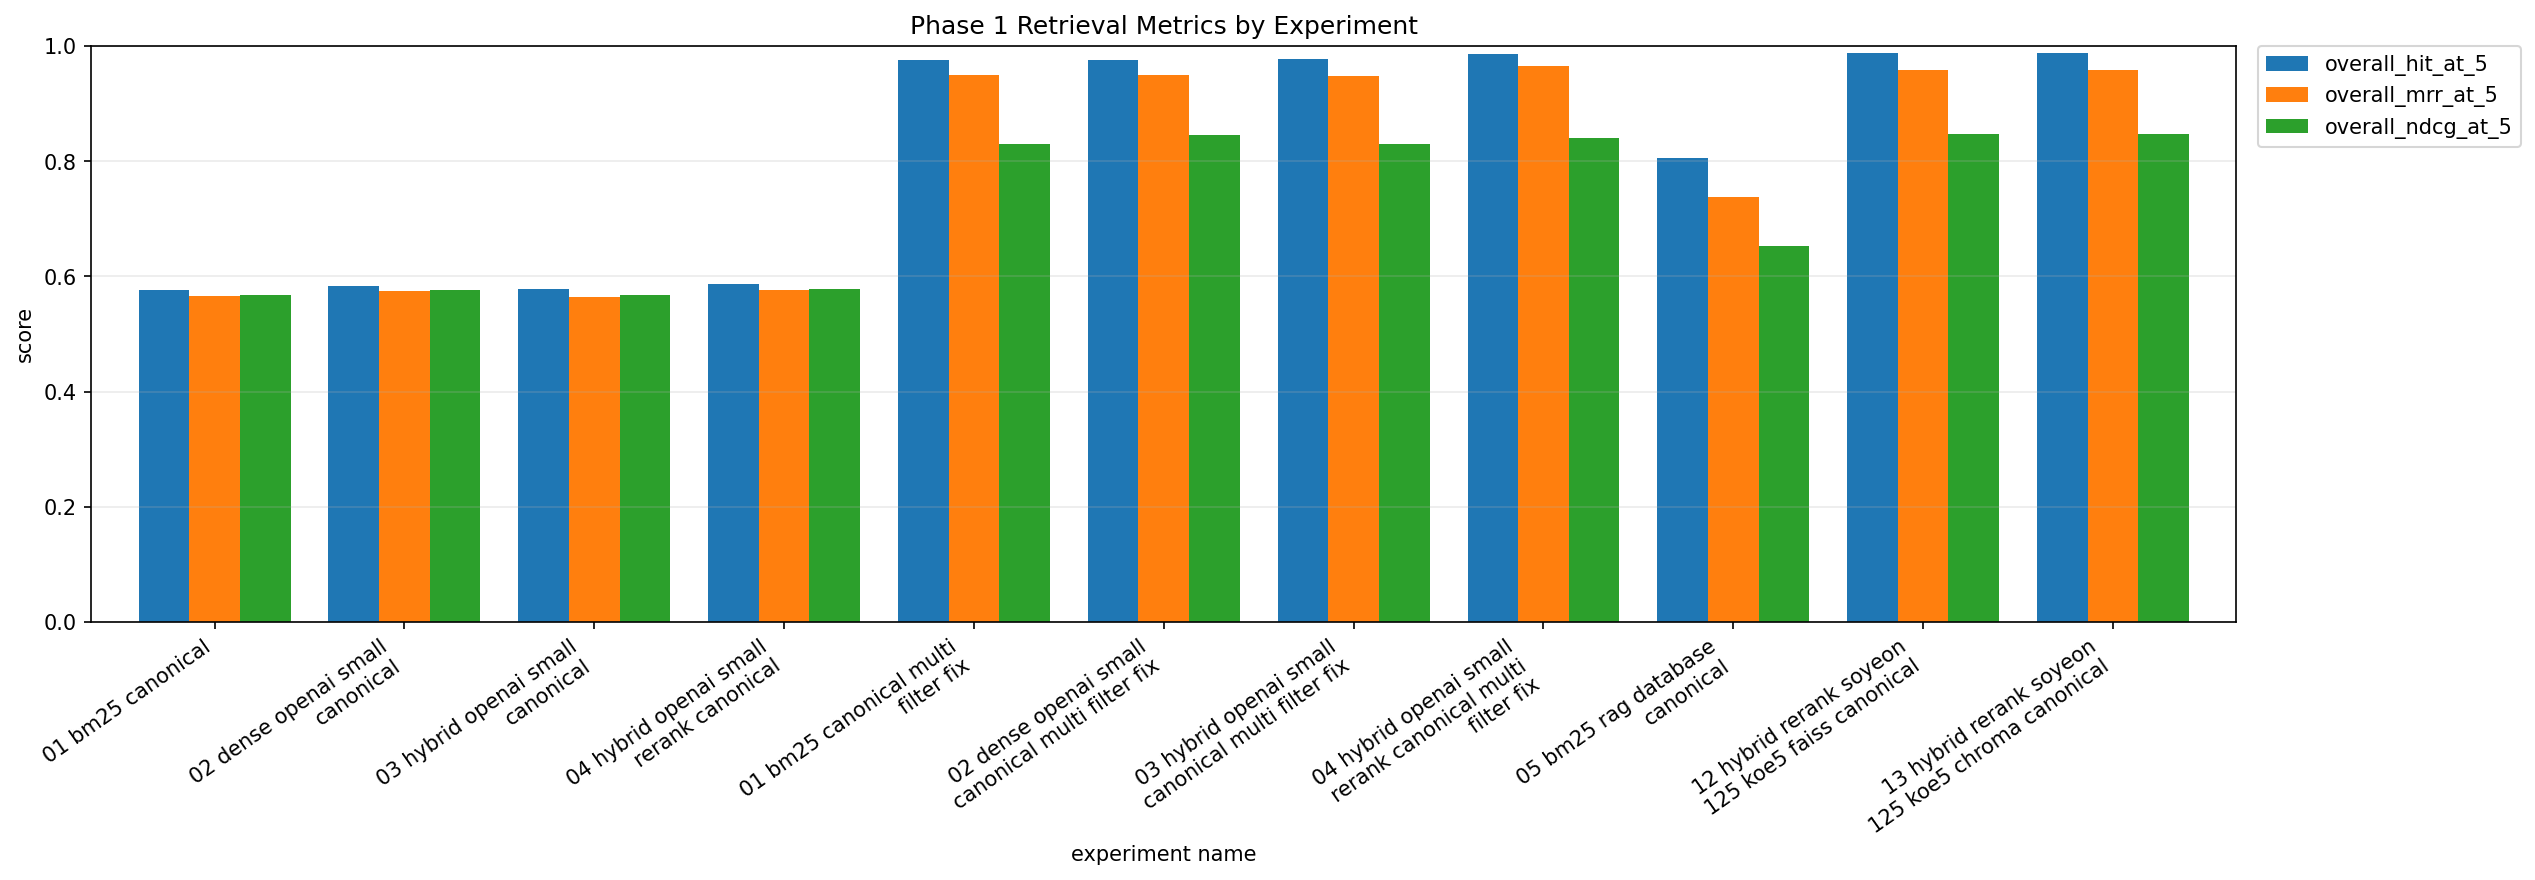

In [ ]:
import matplotlib.pyplot as plt
import textwrap

metric_cols = ["overall_hit_at_5", "overall_mrr_at_5", "overall_ndcg_at_5"]
plot_df = summary.set_index("experiment_name")[metric_cols]

def wrap_experiment_name(label, width=26):
    readable = label.replace("_", " ")
    return "
".join(textwrap.wrap(readable, width=width, break_long_words=False))

wrapped_labels = [wrap_experiment_name(label) for label in plot_df.index]

ax = plot_df.plot(kind="bar", figsize=(17, 6), width=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_xlabel("experiment name")
ax.set_title("Phase 1 Retrieval Metrics by Experiment")
ax.set_xticklabels(wrapped_labels, rotation=35, ha="right")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# 125 chunks

## DB 비교 결과 정리

조건을 고정하고 vector DB만 바꿔서 비교했다.

- 데이터: `/home/codeit/shared_file/dataset/soyeon/125_260520/chunks_v2_125.jsonl`
- 임베딩 모델: `nlpai-lab/KoE5`
- 검색 방식: `hybrid + rerank`
- 평가셋: canonical 500문항
- 답변 생성: 없음, 검색 성능만 평가


In [4]:
db_experiments = [
    "12_hybrid_rerank_soyeon_125_koe5_faiss_canonical",
    "13_hybrid_rerank_soyeon_125_koe5_chroma_canonical",
]

db_meta = pd.DataFrame([
    {
        "experiment_name": "12_hybrid_rerank_soyeon_125_koe5_faiss_canonical",
        "vector_db": "FAISS",
        "build_time": "10m 36s",
        "prediction_time": "2m 05s",
        "index_size": "117M",
    },
    {
        "experiment_name": "13_hybrid_rerank_soyeon_125_koe5_chroma_canonical",
        "vector_db": "Chroma",
        "build_time": "11m 34s",
        "prediction_time": "1m 59s",
        "index_size": "385M",
    },
])

db_compare = (
    summary[summary["experiment_name"].isin(db_experiments)]
    .merge(db_meta, on="experiment_name", how="left")
    [[
        "vector_db",
        "build_time",
        "prediction_time",
        "index_size",
        "embedding_model",
        "retriever_type",
        "reranker",
        "overall_hit_at_5",
        "overall_mrr_at_5",
        "overall_ndcg_at_5",
    ]]
    .sort_values("vector_db")
)

db_compare


,vector_db,build_time,prediction_time,index_size,embedding_model,retriever_type,reranker,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5
1,Chroma,11m 34s,1m 59s,385M,nlpai-lab/KoE5,hybrid,True,0.988,0.959333,0.847099
0,FAISS,10m 36s,2m 05s,117M,nlpai-lab/KoE5,hybrid,True,0.988,0.959333,0.847099


In [6]:
import json

faiss_pred_path = Path("outputs/predictions/12_hybrid_rerank_soyeon_125_koe5_faiss_canonical.jsonl")
chroma_pred_path = Path("outputs/predictions/13_hybrid_rerank_soyeon_125_koe5_chroma_canonical.jsonl")

if not faiss_pred_path.exists():
    faiss_pred_path = Path("../outputs/predictions/12_hybrid_rerank_soyeon_125_koe5_faiss_canonical.jsonl")
if not chroma_pred_path.exists():
    chroma_pred_path = Path("../outputs/predictions/13_hybrid_rerank_soyeon_125_koe5_chroma_canonical.jsonl")

same_top5 = 0
total = 0
first_diff_ids = []

with faiss_pred_path.open(encoding="utf-8") as faiss_file, chroma_pred_path.open(encoding="utf-8") as chroma_file:
    for faiss_line, chroma_line in zip(faiss_file, chroma_file):
        faiss_row = json.loads(faiss_line)
        chroma_row = json.loads(chroma_line)
        total += 1

        faiss_top5 = [(item.get("doc_id"), item.get("chunk_id")) for item in faiss_row.get("retrieved", [])]
        chroma_top5 = [(item.get("doc_id"), item.get("chunk_id")) for item in chroma_row.get("retrieved", [])]

        if faiss_top5 == chroma_top5:
            same_top5 += 1
        elif len(first_diff_ids) < 5:
            first_diff_ids.append(faiss_row.get("id"))

pd.DataFrame([
    {
        "total_questions": total,
        "same_top5_questions": same_top5,
        "different_top5_questions": total - same_top5,
        "first_diff_ids": first_diff_ids,
    }
])


,total_questions,same_top5_questions,different_top5_questions,first_diff_ids
0,500,500,0,[]


### DB 비교 결론

FAISS와 Chroma는 이번 조건에서 검색 점수가 완전히 같았다. 추가로 prediction 파일을 직접 비교했을 때도 500개 질문 전부 top-5 검색 결과가 동일했다.

따라서 현재 조건에서는 FAISS를 우선 사용하는 쪽이 낫다. 성능은 같고, 인덱스 용량은 FAISS가 `117M`, Chroma가 `385M`로 FAISS가 더 작다.


# 임베딩 모델 결과 비교

## kure vs bge-m3 vs koe5

조건은 DB 비교 실험과 동일하게 두고, 임베딩 모델만 바꿔서 비교했다.

- 데이터: `/home/codeit/shared_file/dataset/soyeon/125_260520/chunks_v2_125.jsonl`
- DB: `FAISS`
- 검색 방식: `hybrid + rerank`
- 평가셋: canonical 500문항
- 답변 생성: 없음, 검색 성능만 평가


In [ ]:
embedding_experiments = [
    "12_hybrid_rerank_soyeon_125_koe5_faiss_canonical",
    "14_hybrid_rerank_soyeon_125_bge_m3_faiss_canonical",
    "15_hybrid_rerank_soyeon_125_kure_faiss_canonical",
]

embedding_meta = pd.DataFrame([
    {
        "experiment_name": "12_hybrid_rerank_soyeon_125_koe5_faiss_canonical",
        "embedding": "KoE5",
        "build_time": "10m 36s",
        "prediction_time": "2m 05s",
        "index_size": "117M",
    },
    {
        "experiment_name": "14_hybrid_rerank_soyeon_125_bge_m3_faiss_canonical",
        "embedding": "bge-m3",
        "build_time": "12m 34s",
        "prediction_time": "2m 05s",
        "index_size": "117M",
    },
    {
        "experiment_name": "15_hybrid_rerank_soyeon_125_kure_faiss_canonical",
        "embedding": "KURE-v1",
        "build_time": "12m 50s",
        "prediction_time": "1m 51s",
        "index_size": "117M",
    },
])

embedding_compare = (
    summary[summary["experiment_name"].isin(embedding_experiments)]
    .merge(embedding_meta, on="experiment_name", how="left")
)
embedding_compare["_order"] = embedding_compare["experiment_name"].map(
    {name: idx for idx, name in enumerate(embedding_experiments)}
)
embedding_compare = (
    embedding_compare
    .sort_values("_order")
    .rename(columns={
        "embedding_model": "model_id",
        "retriever_type": "retriever",
        "reranker": "rerank",
        "overall_hit_at_5": "hit@5",
        "overall_mrr_at_5": "mrr@5",
        "overall_ndcg_at_5": "ndcg@5",
    })
    [[
        "embedding",
        "model_id",
        "retriever",
        "rerank",
        "build_time",
        "prediction_time",
        "index_size",
        "hit@5",
        "mrr@5",
        "ndcg@5",
    ]]
)

for metric in ["hit@5", "mrr@5", "ndcg@5"]:
    embedding_compare[metric] = embedding_compare[metric].round(4)

embedding_compare


embedding,model_id,retriever,rerank,build_time,prediction_time,index_size,hit@5,mrr@5,ndcg@5
KoE5,nlpai-lab/KoE5,hybrid,True,10m 36s,2m 05s,117M,0.988,0.9593,0.8471
bge-m3,BAAI/bge-m3,hybrid,True,12m 34s,2m 05s,117M,0.988,0.9592,0.8467
KURE-v1,nlpai-lab/KURE-v1,hybrid,True,12m 50s,1m 51s,117M,0.988,0.9592,0.8470


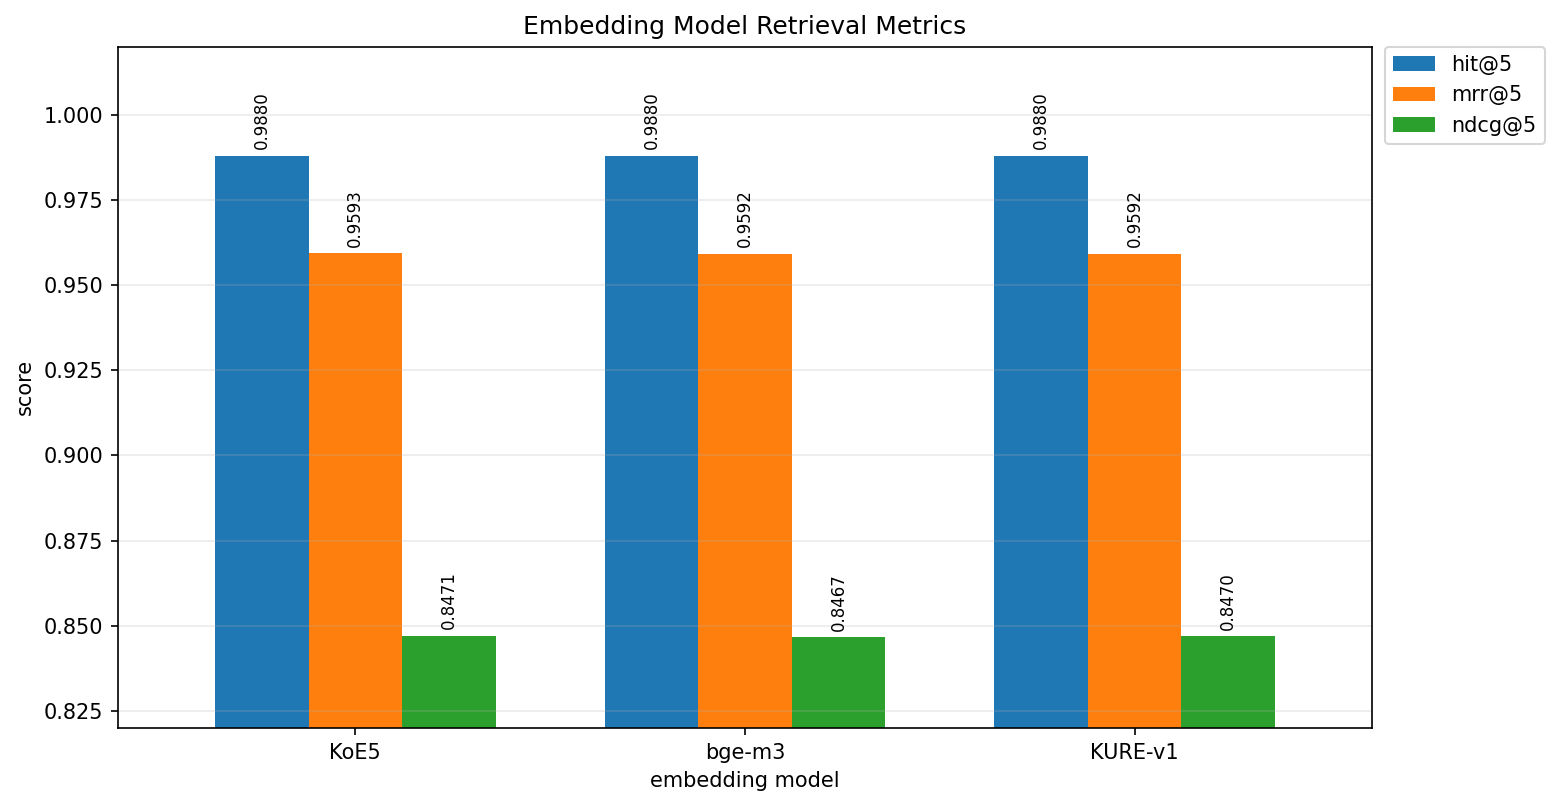

In [ ]:
import matplotlib.pyplot as plt

embedding_metric_cols = ["hit@5", "mrr@5", "ndcg@5"]
plot_df = embedding_compare.set_index("embedding")[embedding_metric_cols]

ax = plot_df.plot(kind="bar", figsize=(10.5, 5.5), width=0.72)
ax.set_ylim(0.82, 1.02)
ax.set_ylabel("score")
ax.set_xlabel("embedding model")
ax.set_title("Embedding Model Retrieval Metrics")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, rotation=90, padding=3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 임베딩 모델 비교 결론

세 모델 모두 `hit@5`는 `0.988`로 동일했다. `mrr@5`와 `ndcg@5`도 차이가 매우 작아서, 현재 125 데이터 기준에서는 성능 차이가 거의 없다고 볼 수 있다.

아주 미세하게는 KoE5가 `mrr@5`, `ndcg@5`에서 가장 높지만, bge-m3와 KURE-v1도 사실상 같은 성능권이다. 빌드 시간까지 고려하면 현재 조건에서는 KoE5를 우선 후보로 두고, 다음 단계에서는 데이터 범위를 넓히거나 실패 케이스 기준으로 비교하는 편이 좋다.


# 1단계: 문서 다양성 + fetch-k 확대

기존 hybrid+rerank는 chunk 단위 점수만 보고 top-5를 뽑았기 때문에, 같은 문서의 여러 chunk가 상위권을 차지할 수 있었다. 이번 실험은 내부 후보를 100개까지 가져온 뒤, 최종 top-5는 `doc_id` 기준으로 서로 다른 문서가 먼저 들어오도록 바꾼 것이다.

실험 조건: KoE5 + FAISS + Hybrid + keyword rerank, canonical 500문항, 답변 생성 없음.


In [14]:
import json
import pandas as pd

log_path = "../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"
df = pd.read_csv(log_path)

baseline_name = "12_hybrid_rerank_soyeon_125_koe5_faiss_canonical"
diverse_name = "16_hybrid_rerank_diverse_fetch100_soyeon_125_koe5_faiss_canonical"

def latest(name):
    rows = df[df["experiment_name"] == name].copy()
    rows["run_datetime"] = pd.to_datetime(rows["run_datetime"])
    return rows.sort_values("run_datetime").iloc[-1]

def type_metric(row, target_type, metric):
    for item in json.loads(row["by_type_summary_json"]):
        if item["type"] == target_type:
            return item[metric]

def difficulty_metric(row, target_difficulty, metric):
    for item in json.loads(row["by_difficulty_summary_json"]):
        if item["difficulty"] == target_difficulty:
            return item[metric]

base = latest(baseline_name)
div = latest(diverse_name)

compare = pd.DataFrame([
    {
        "experiment": "baseline: hybrid+rerank",
        "hit@5": base["overall_hit_at_5"],
        "mrr@5": base["overall_mrr_at_5"],
        "ndcg@5": base["overall_ndcg_at_5"],
        "type B ndcg@5": type_metric(base, "B", "ndcg_at_5"),
        "hard ndcg@5": difficulty_metric(base, "상", "ndcg_at_5"),
    },
    {
        "experiment": "diverse: fetch100+doc diversity",
        "hit@5": div["overall_hit_at_5"],
        "mrr@5": div["overall_mrr_at_5"],
        "ndcg@5": div["overall_ndcg_at_5"],
        "type B ndcg@5": type_metric(div, "B", "ndcg_at_5"),
        "hard ndcg@5": difficulty_metric(div, "상", "ndcg_at_5"),
    },
])

delta = compare.iloc[1, 1:].astype(float) - compare.iloc[0, 1:].astype(float)
compare_display = compare.copy()
for col in compare_display.columns[1:]:
    compare_display[col] = compare_display[col].map(lambda v: f"{v:.4f}")
compare_display = pd.concat([
    compare_display,
    pd.DataFrame([{"experiment": "delta", **{col: f"{value:+.4f}" for col, value in delta.items()}}]),
], ignore_index=True)

compare_display


experiment,hit@5,mrr@5,ndcg@5,type B ndcg@5,hard ndcg@5
baseline: hybrid+rerank,0.9880,0.9593,0.8471,0.6724,0.7820
diverse: fetch100+doc diversity,0.9940,0.9622,0.9201,0.8468,0.8636
delta,+0.0060,+0.0028,+0.0730,+0.1744,+0.0815


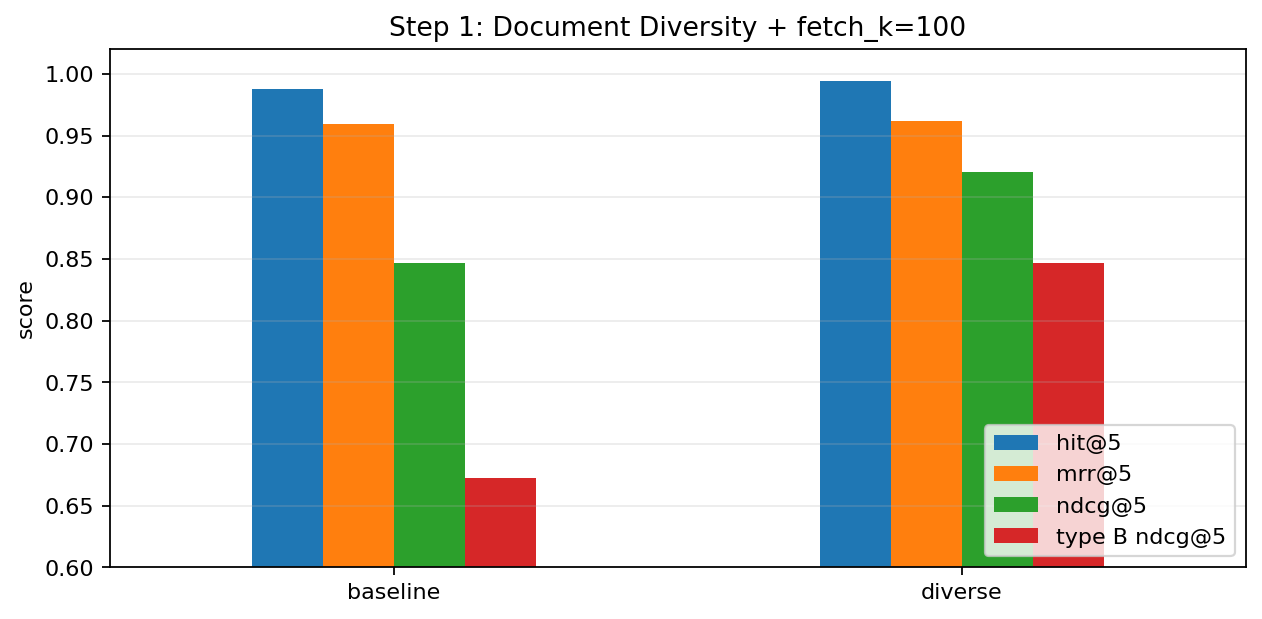

In [15]:
import matplotlib.pyplot as plt

plot_df = compare.set_index("experiment")[["hit@5", "mrr@5", "ndcg@5", "type B ndcg@5"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Step 1: Document Diversity + fetch_k=100")
ax.set_ylim(0.6, 1.02)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 1단계 결론

문서 다양성 보장은 바로 효과가 있었다. 전체 `ndcg@5`가 `0.8471`에서 `0.9201`로 올랐고, 특히 다중 문서 질문인 type B의 `ndcg@5`가 `0.6724`에서 `0.8468`로 크게 개선됐다.

해석하면, 모델이 정답 문서를 아예 못 찾는 문제보다 같은 정답/유사 문서의 chunk가 top-5를 점유해서 다른 정답 문서가 밀리는 문제가 더 컸다. 그래서 다음 실험부터는 `fetch_k=100 + doc_id 다양성`을 기본 조건으로 두고 hybrid 가중치를 튜닝하는 게 맞다.


# 2단계: Hybrid 가중치 튜닝

1단계에서 효과가 좋았던 `fetch_k=100 + doc_id 다양성`은 유지하고, BM25와 Dense 점수 결합 비율만 바꿔서 비교했다. 목표는 이 데이터가 키워드 검색에 더 강한지, 의미 검색에 더 강한지 확인하는 것이다.

공통 조건: KoE5 + FAISS + Hybrid + keyword rerank + document diversity, canonical 500문항, 답변 생성 없음.


In [16]:
import json
import pandas as pd

log_path = "../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"
df = pd.read_csv(log_path)
experiments = [
    ("0.5 / 0.5", "16_hybrid_rerank_diverse_fetch100_soyeon_125_koe5_faiss_canonical"),
    ("0.7 / 0.3", "17_hybrid_rerank_diverse_fetch100_bm25_07_dense_03_soyeon_125_koe5_faiss_canonical"),
    ("0.3 / 0.7", "18_hybrid_rerank_diverse_fetch100_bm25_03_dense_07_soyeon_125_koe5_faiss_canonical"),
]

def latest(name):
    rows = df[df["experiment_name"] == name].copy()
    rows["run_datetime"] = pd.to_datetime(rows["run_datetime"])
    return rows.sort_values("run_datetime").iloc[-1]

def type_metric(row, target_type, metric):
    for item in json.loads(row["by_type_summary_json"]):
        if item["type"] == target_type:
            return item[metric]

weight_compare = pd.DataFrame([
    {
        "bm25 / dense": label,
        "hit@5": row["overall_hit_at_5"],
        "mrr@5": row["overall_mrr_at_5"],
        "ndcg@5": row["overall_ndcg_at_5"],
        "type B ndcg@5": type_metric(row, "B", "ndcg_at_5"),
    }
    for label, name in experiments
    for row in [latest(name)]
])

weight_compare_display = weight_compare.copy()
for col in weight_compare_display.columns[1:]:
    weight_compare_display[col] = weight_compare_display[col].map(lambda v: f"{v:.4f}")
weight_compare_display


bm25 / dense,hit@5,mrr@5,ndcg@5,type B ndcg@5
0.5 / 0.5,0.9940,0.9622,0.9201,0.8468
0.7 / 0.3,0.9940,0.9642,0.9213,0.8481
0.3 / 0.7,0.9940,0.9582,0.9177,0.8445


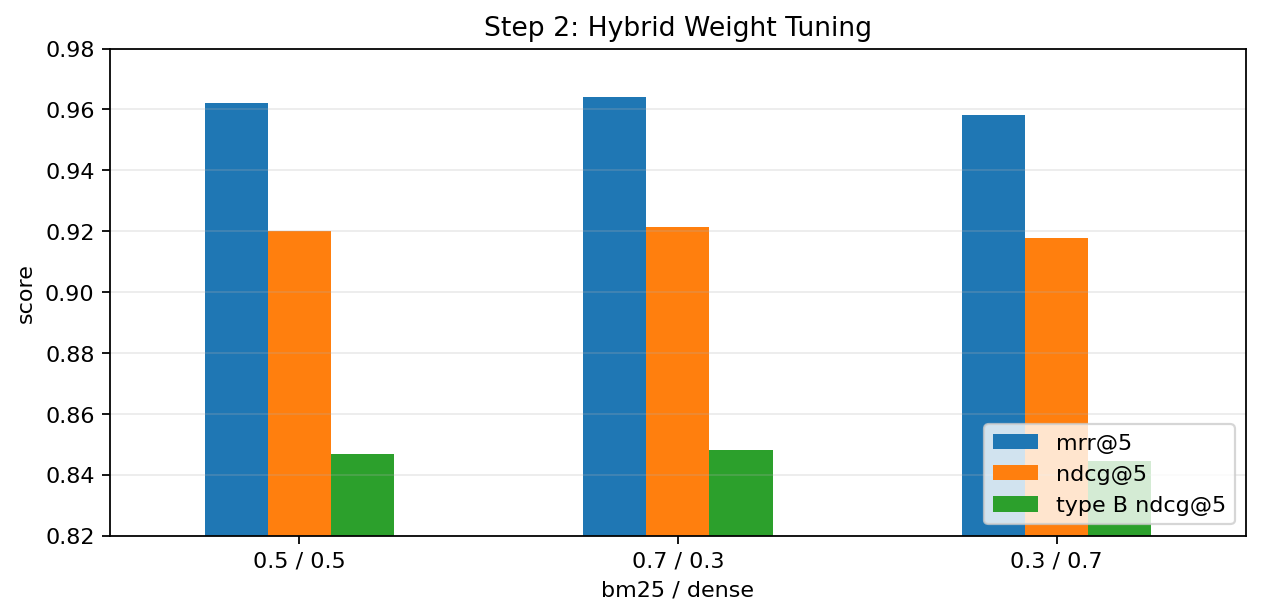

In [17]:
import matplotlib.pyplot as plt

plot_df = weight_compare.set_index("bm25 / dense")[["mrr@5", "ndcg@5", "type B ndcg@5"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Step 2: Hybrid Weight Tuning")
ax.set_ylim(0.82, 0.98)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 2단계 결론

가장 좋은 설정은 `BM25 / Dense = 0.7 / 0.3`였다. 전체 `ndcg@5` 기준으로 `0.9201`에서 `0.9213`로 소폭 상승했고, `mrr@5`도 `0.9622`에서 `0.9642`로 올랐다.

다만 상승폭은 1단계 문서 다양성 개선에 비하면 작다. 현재 데이터에서는 BM25 비중을 조금 높이는 쪽이 유리하지만, 핵심 개선 포인트는 여전히 “후보를 넓게 가져오고 문서 단위로 다양하게 정리하는 것”이다.


# 3단계: Dense-only 비교

이번에는 BM25를 완전히 빼고 Dense 검색만 사용했다. 다만 1단계에서 효과가 컸던 `rerank_candidates=100 + doc_id 다양성`은 유지했다. 목적은 hybrid가 꼭 필요한지, 아니면 dense만으로도 충분한지 확인하는 것이다.

공통 조건: KoE5 + FAISS + keyword rerank + document diversity, canonical 500문항, 답변 생성 없음.


In [18]:
import json
import pandas as pd

log_path = "../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"
df = pd.read_csv(log_path)
experiments = [
    ("hybrid best: bm25 0.7 / dense 0.3", "17_hybrid_rerank_diverse_fetch100_bm25_07_dense_03_soyeon_125_koe5_faiss_canonical", "2:28"),
    ("dense only", "19_dense_rerank_diverse100_soyeon_125_koe5_faiss_canonical", "0:50"),
]

def latest(name):
    rows = df[df["experiment_name"] == name].copy()
    rows["run_datetime"] = pd.to_datetime(rows["run_datetime"])
    return rows.sort_values("run_datetime").iloc[-1]

def type_metric(row, target_type, metric):
    for item in json.loads(row["by_type_summary_json"]):
        if item["type"] == target_type:
            return item[metric]

dense_compare = pd.DataFrame([
    {
        "retriever": label,
        "elapsed": elapsed,
        "hit@5": row["overall_hit_at_5"],
        "mrr@5": row["overall_mrr_at_5"],
        "ndcg@5": row["overall_ndcg_at_5"],
        "type B ndcg@5": type_metric(row, "B", "ndcg_at_5"),
    }
    for label, name, elapsed in experiments
    for row in [latest(name)]
])

dense_compare_display = dense_compare.copy()
for col in ["hit@5", "mrr@5", "ndcg@5", "type B ndcg@5"]:
    dense_compare_display[col] = dense_compare_display[col].map(lambda v: f"{v:.4f}")
dense_compare_display


retriever,elapsed,hit@5,mrr@5,ndcg@5,type B ndcg@5
hybrid best: bm25 0.7 / dense 0.3,2:28,0.9940,0.9642,0.9213,0.8481
dense only,0:50,0.9980,0.9585,0.9238,0.8566


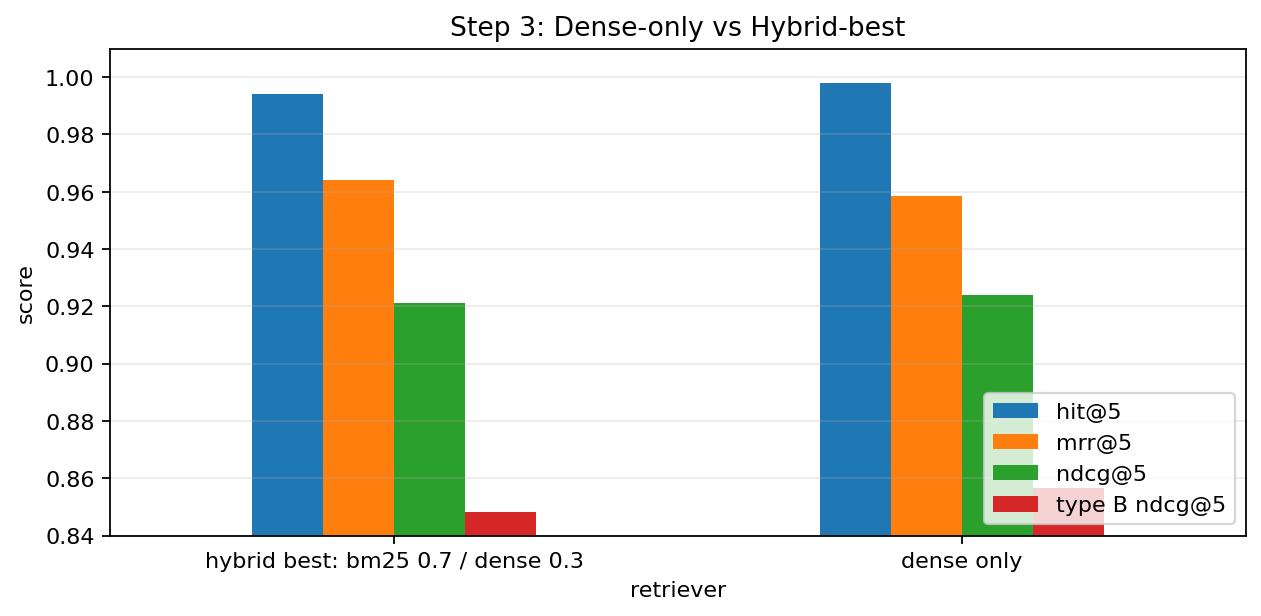

In [19]:
import matplotlib.pyplot as plt

plot_df = dense_compare.set_index("retriever")[["hit@5", "mrr@5", "ndcg@5", "type B ndcg@5"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Step 3: Dense-only vs Hybrid-best")
ax.set_ylim(0.84, 1.01)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 3단계 결론

Dense-only가 예상보다 좋았다. Hybrid best 대비 `hit@5`는 `+0.0040`, `ndcg@5`는 `+0.0025`로 소폭 높았고, type B `ndcg@5`도 더 좋았다. 대신 `mrr@5`는 `-0.0057` 낮아서 첫 번째 순위에 정답을 놓는 능력은 hybrid가 조금 더 낫다.

실행 시간도 차이가 컸다. 이번 로그 기준 dense-only 예측은 약 50초, hybrid best는 약 2분 28초였다. 현 단계에서는 “생성에 넣을 top-5 문서 품질”을 우선하면 dense-only도 강한 후보이고, “1등 문서 순위”를 우선하면 hybrid best가 후보로 남는다.


# 4단계: Reranker ablation

현재 reranker는 cross-encoder 같은 별도 모델이 아니라, 질문과 후보 chunk의 키워드 겹침을 기준으로 재정렬하는 가벼운 local reranker다. 그래서 정말 도움이 되는지 확인하기 위해 dense+diversity 조건에서 세 가지를 비교했다.

공통 조건: KoE5 + FAISS + Dense + document diversity, canonical 500문항, 답변 생성 없음.


In [20]:
import json
import pandas as pd

log_path = "../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"
df = pd.read_csv(log_path)
experiments = [
    ("rerank default 0.01", "19_dense_rerank_diverse100_soyeon_125_koe5_faiss_canonical", "0:50"),
    ("no rerank", "20_dense_diverse100_no_rerank_soyeon_125_koe5_faiss_canonical", "0:45"),
    ("rerank original 0.10", "21_dense_rerank_weight010_diverse100_soyeon_125_koe5_faiss_canonical", "0:48"),
]

def latest(name):
    rows = df[df["experiment_name"] == name].copy()
    rows["run_datetime"] = pd.to_datetime(rows["run_datetime"])
    return rows.sort_values("run_datetime").iloc[-1]

def type_metric(row, target_type, metric):
    for item in json.loads(row["by_type_summary_json"]):
        if item["type"] == target_type:
            return item[metric]

rerank_compare = pd.DataFrame([
    {
        "rerank setting": label,
        "elapsed": elapsed,
        "hit@5": row["overall_hit_at_5"],
        "mrr@5": row["overall_mrr_at_5"],
        "ndcg@5": row["overall_ndcg_at_5"],
        "type B ndcg@5": type_metric(row, "B", "ndcg_at_5"),
    }
    for label, name, elapsed in experiments
    for row in [latest(name)]
])

rerank_compare_display = rerank_compare.copy()
for col in ["hit@5", "mrr@5", "ndcg@5", "type B ndcg@5"]:
    rerank_compare_display[col] = rerank_compare_display[col].map(lambda v: f"{v:.4f}")
rerank_compare_display


rerank setting,elapsed,hit@5,mrr@5,ndcg@5,type B ndcg@5
rerank default 0.01,0:50,0.9980,0.9585,0.9238,0.8566
no rerank,0:45,0.9980,0.9708,0.9286,0.8498
rerank original 0.10,0:48,0.9980,0.9575,0.9235,0.8558


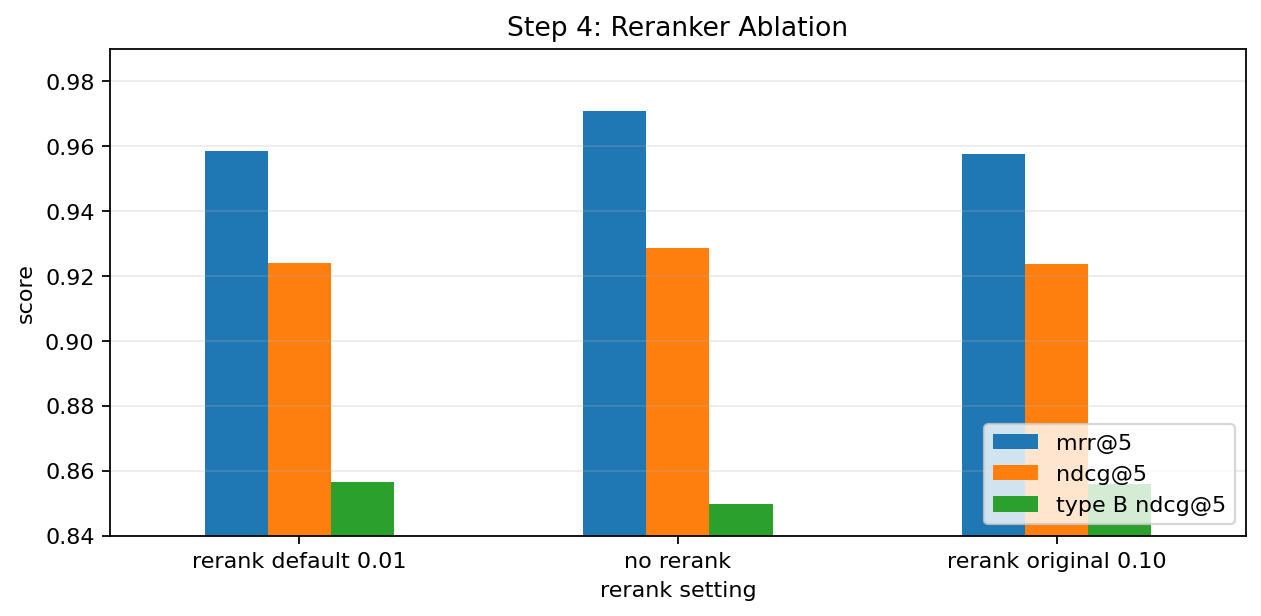

In [21]:
import matplotlib.pyplot as plt

plot_df = rerank_compare.set_index("rerank setting")[["mrr@5", "ndcg@5", "type B ndcg@5"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Step 4: Reranker Ablation")
ax.set_ylim(0.84, 0.99)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 4단계 결론

현재 local keyword reranker는 dense+diversity 조건에서는 도움이 되지 않았다. 가장 좋은 설정은 `no rerank`였고, 기본 rerank 대비 `ndcg@5`는 `+0.0048`, `mrr@5`는 `+0.0123` 개선됐다.

따라서 현재 best 후보는 `Dense + FAISS + KoE5 + doc_id 다양성 + rerank 없음`이다. 이후 reranker를 다시 개선하려면 단순 키워드 방식보다 cross-encoder/bge-reranker 계열처럼 query-document pair를 직접 점수화하는 모델을 붙여서 비교하는 쪽이 더 의미 있어 보인다.


# 5단계: 문서명 정규화 개선

최신 best 결과에서 남은 실패 케이스는 실제 검색이 틀렸다기보다 ground truth 문서명 표기 오류에 가까웠다. 예측 문서명은 `인천공항운영서비스...`였고, ground truth에는 `인천공항운서비스...`처럼 한 글자가 빠져 있었다.

그래서 평가 코드에 비교용 문서 key를 추가했다. 원문 출력은 그대로 보존하고, 비교할 때만 NFKC 정규화, 회사 표기 정규화, 확장자 제거, 특수문자 제거를 적용한다. 추가로 같은 기관 prefix이며 긴 파일명일 때만 유사도 0.98 이상의 오타성 차이를 허용했다.


In [22]:
import pandas as pd

log_path = "../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"
df = pd.read_csv(log_path)
experiments = [
    ("before doc normalization", "20_dense_diverse100_no_rerank_soyeon_125_koe5_faiss_canonical"),
    ("after doc normalization", "22_dense_diverse100_no_rerank_docnorm_soyeon_125_koe5_faiss_canonical"),
]

def latest(name):
    rows = df[df["experiment_name"] == name].copy()
    rows["run_datetime"] = pd.to_datetime(rows["run_datetime"])
    return rows.sort_values("run_datetime").iloc[-1]

docnorm_compare = pd.DataFrame([
    {
        "setting": label,
        "hit@5": row["overall_hit_at_5"],
        "mrr@5": row["overall_mrr_at_5"],
        "ndcg@5": row["overall_ndcg_at_5"],
        "num_scored": row["num_scored_questions"],
    }
    for label, name in experiments
    for row in [latest(name)]
])

docnorm_compare_display = docnorm_compare.copy()
for col in ["hit@5", "mrr@5", "ndcg@5"]:
    docnorm_compare_display[col] = docnorm_compare_display[col].map(lambda v: f"{v:.4f}")
docnorm_compare_display


setting,hit@5,mrr@5,ndcg@5,num_scored
before doc normalization,0.9980,0.9708,0.9286,500
after doc normalization,1.0000,0.9728,0.9306,500


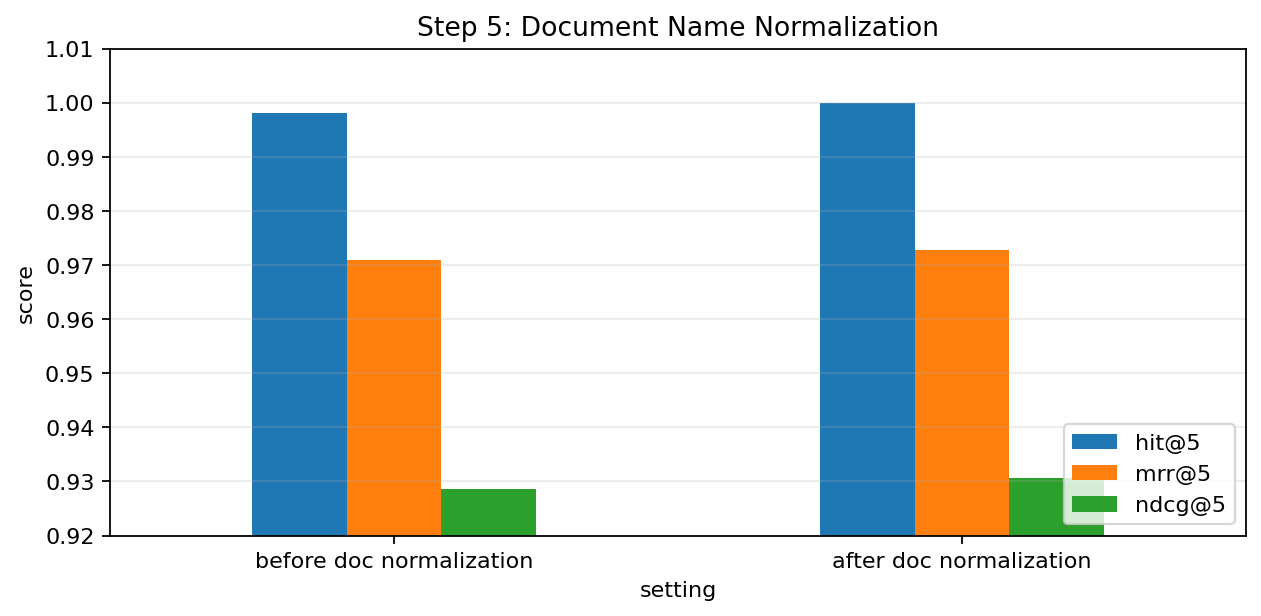

In [23]:
import matplotlib.pyplot as plt

plot_df = docnorm_compare.set_index("setting")[["hit@5", "mrr@5", "ndcg@5"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Step 5: Document Name Normalization")
ax.set_ylim(0.92, 1.01)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 5단계 결론

문서명 정규화 후 `hit@5`는 `0.9980`에서 `1.0000`로 올라갔고, 실패 케이스는 0개가 됐다. `ndcg@5`도 `0.9286`에서 `0.9306`로 소폭 상승했다.

주의할 점은 이 개선은 검색 로직 자체가 좋아진 것이 아니라, 평가에서 명백한 문서명 표기 흔들림을 더 공정하게 처리한 것이다. 공식 평가가 완전 exact match라면 이 점수와 차이가 날 수 있으므로, 실험 로그에는 `docnorm` 실험으로 분리해서 기록했다.


# 6단계: Best 조건에서 임베딩 모델 재비교

이전 임베딩 비교는 hybrid+rerank 조건이었기 때문에, 새 best 조건과는 기준이 달랐다. 이번에는 `Dense + FAISS + doc_id 다양성 + rerank 없음 + 문서명 정규화 평가`로 조건을 맞추고 KoE5, bge-m3, KURE를 다시 비교했다.


In [24]:
import json
import pandas as pd

log_path = "../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"
df = pd.read_csv(log_path)
experiments = [
    ("KoE5", "22_dense_diverse100_no_rerank_docnorm_soyeon_125_koe5_faiss_canonical", "0:45"),
    ("bge-m3", "23_dense_diverse100_soyeon_125_bge_m3_faiss_canonical", "0:59"),
    ("KURE", "24_dense_diverse100_soyeon_125_kure_faiss_canonical", "0:59"),
]

def latest(name):
    rows = df[df["experiment_name"] == name].copy()
    rows["run_datetime"] = pd.to_datetime(rows["run_datetime"])
    return rows.sort_values("run_datetime").iloc[-1]

def type_metric(row, target_type, metric):
    for item in json.loads(row["by_type_summary_json"]):
        if item["type"] == target_type:
            return item[metric]

best_embedding_compare = pd.DataFrame([
    {
        "embedding": label,
        "elapsed": elapsed,
        "hit@5": row["overall_hit_at_5"],
        "mrr@5": row["overall_mrr_at_5"],
        "ndcg@5": row["overall_ndcg_at_5"],
        "type B ndcg@5": type_metric(row, "B", "ndcg_at_5"),
    }
    for label, name, elapsed in experiments
    for row in [latest(name)]
])

best_embedding_compare_display = best_embedding_compare.copy()
for col in ["hit@5", "mrr@5", "ndcg@5", "type B ndcg@5"]:
    best_embedding_compare_display[col] = best_embedding_compare_display[col].map(lambda v: f"{v:.4f}")
best_embedding_compare_display


embedding,elapsed,hit@5,mrr@5,ndcg@5,type B ndcg@5
KoE5,0:45,1.0000,0.9728,0.9306,0.8498
bge-m3,0:59,1.0000,0.9595,0.9164,0.8324
KURE,0:59,1.0000,0.9696,0.9259,0.8420


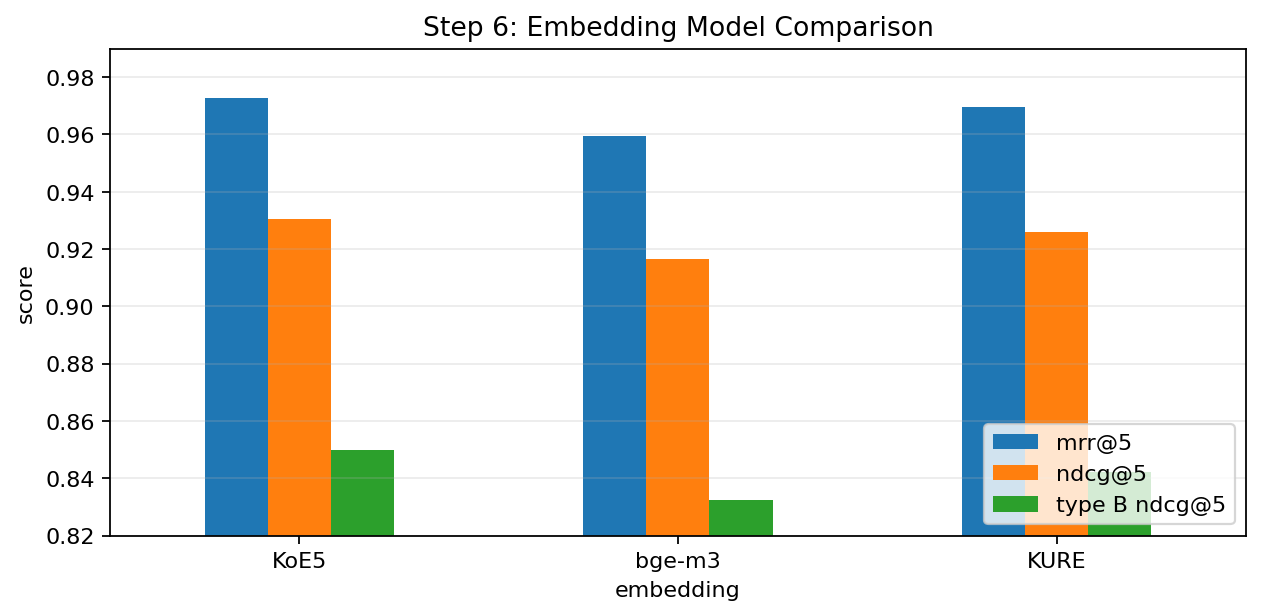

In [25]:
import matplotlib.pyplot as plt

plot_df = best_embedding_compare.set_index("embedding")[["mrr@5", "ndcg@5", "type B ndcg@5"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Step 6: Embedding Model Comparison")
ax.set_ylim(0.82, 0.99)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 6단계 결론

같은 best 조건에서는 `KoE5`가 가장 좋았다. 세 모델 모두 `hit@5 = 1.0`까지 도달했지만, 순위 품질을 보는 `mrr@5`와 `ndcg@5`에서 차이가 났다. `ndcg@5` 기준 최고 점수는 `0.9306`이고, 2위와의 차이는 `+0.0047`다.

현재 데이터에서는 KoE5가 가장 안정적이므로, 이후 성능 개선 실험은 KoE5 인덱스를 기준으로 이어가는 것이 좋다.


# 7단계: Reranker 고도화

기존 keyword reranker가 전체 점수를 낮췄기 때문에, cross-encoder reranker를 선택 옵션으로 추가했다. 모델은 `BAAI/bge-reranker-v2-m3`를 사용했고, VM에서 전체 500문항을 돌릴 수 있도록 후보 수와 입력 길이를 줄인 설정을 먼저 평가했다.

비교한 방식은 네 가지다.

- `no rerank`: 현재 best, Dense + FAISS + KoE5 + doc_id 다양성
- `keyword rerank`: 기존 local keyword overlap reranker
- `cross before diversity`: 후보 10개를 cross-encoder로 먼저 재정렬한 뒤 다양성 적용
- `cross after diversity`: dense 후보 100개에서 문서 다양성으로 10개를 고른 뒤 cross-encoder 재정렬

참고로 후보 30개 cross-encoder 전체 실험은 VM에서 너무 오래 걸려 중단했다. 후보 10개 실험은 약 3분 정도로 실행 가능했다.


In [26]:
import json
import pandas as pd

log_path = "../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"
df = pd.read_csv(log_path)
experiments = [
    ("no rerank", "22_dense_diverse100_no_rerank_docnorm_soyeon_125_koe5_faiss_canonical", "0:45"),
    ("keyword rerank", "27_dense_keyword_rerank_diverse100_docnorm_soyeon_125_koe5_faiss_canonical", "0:50"),
    ("cross before diversity", "25_dense_cross_encoder_rerank10_diverse10_soyeon_125_koe5_faiss_canonical", "3:06"),
    ("cross after diversity", "26_dense_diverse100_cross_encoder_rerank10_soyeon_125_koe5_faiss_canonical", "3:13"),
]

def latest(name):
    rows = df[df["experiment_name"] == name].copy()
    rows["run_datetime"] = pd.to_datetime(rows["run_datetime"])
    return rows.sort_values("run_datetime").iloc[-1]

def type_metric(row, target_type, metric):
    for item in json.loads(row["by_type_summary_json"]):
        if item["type"] == target_type:
            return item[metric]

reranker_improvement_compare = pd.DataFrame([
    {
        "reranker": label,
        "elapsed": elapsed,
        "hit@5": row["overall_hit_at_5"],
        "mrr@5": row["overall_mrr_at_5"],
        "ndcg@5": row["overall_ndcg_at_5"],
        "type B ndcg@5": type_metric(row, "B", "ndcg_at_5"),
    }
    for label, name, elapsed in experiments
    for row in [latest(name)]
])

reranker_improvement_display = reranker_improvement_compare.copy()
for col in ["hit@5", "mrr@5", "ndcg@5", "type B ndcg@5"]:
    reranker_improvement_display[col] = reranker_improvement_display[col].map(lambda v: f"{v:.4f}")
reranker_improvement_display


reranker,elapsed,hit@5,mrr@5,ndcg@5,type B ndcg@5
no rerank,0:45,1.0000,0.9728,0.9306,0.8498
keyword rerank,0:50,1.0000,0.9605,0.9258,0.8566
cross before diversity,3:06,1.0000,0.9648,0.9041,0.7904
cross after diversity,3:13,0.9840,0.9643,0.8652,0.7026


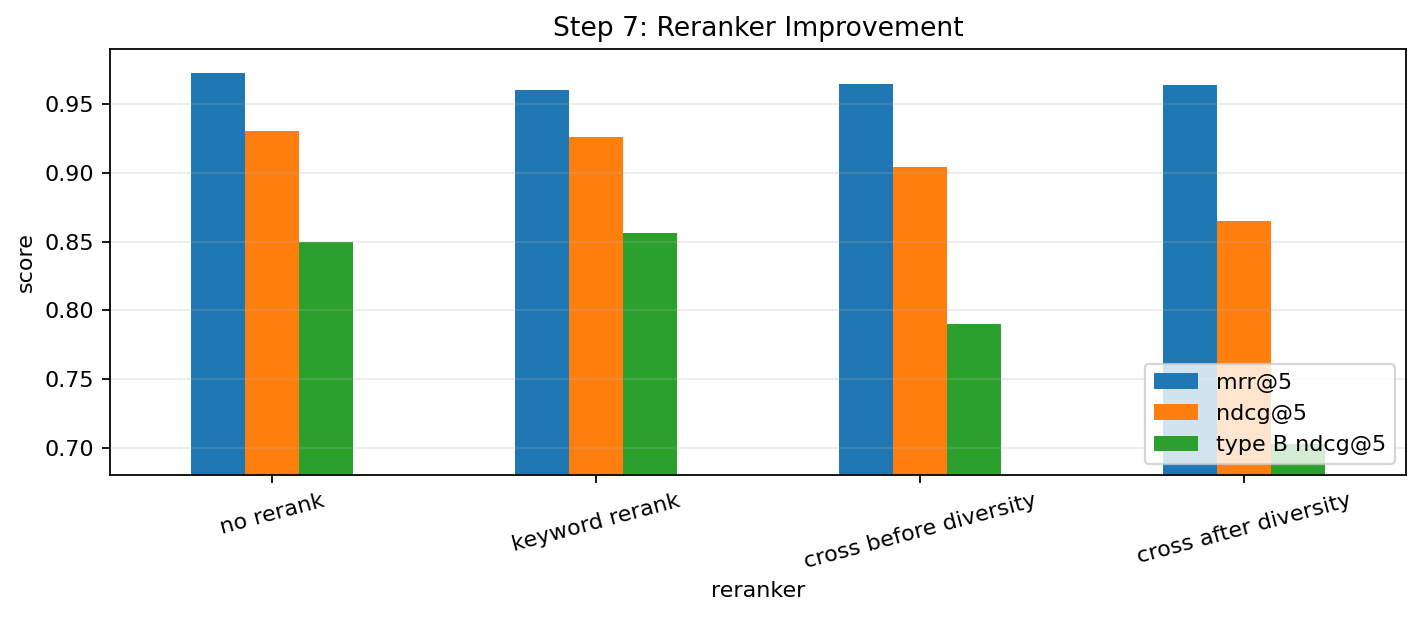

In [27]:
import matplotlib.pyplot as plt

plot_df = reranker_improvement_compare.set_index("reranker")[["mrr@5", "ndcg@5", "type B ndcg@5"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4), rot=15)
ax.set_title("Step 7: Reranker Improvement")
ax.set_ylim(0.68, 0.99)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 7단계 결론

현재 기준에서는 `no rerank`가 가장 좋다. `ndcg@5`는 `0.9306`로 가장 높았고, keyword rerank는 `0.9258`, cross-encoder after-diversity는 `0.8652`였다.

해석하면, 이 데이터에서는 dense 검색 순위 자체가 이미 강하고, 가벼운 reranker나 짧은 입력의 cross-encoder가 오히려 좋은 순서를 흔드는 경향이 있다. cross-encoder를 계속 쓰려면 다음에는 후보 100개를 그대로 재정렬하기보다 “문서별 대표 chunk 선별 → cross-encoder 재정렬”처럼 입력 후보를 더 잘 구성해야 한다.


# 8단계: BM25 tokenizer 개선

BM25가 기존에는 `split()` 기반 whitespace tokenization만 사용했다. 이 방식은 괄호, 쉼표, 확장자, 영문/숫자/한글이 붙은 표현을 그대로 하나의 토큰으로 다루기 때문에 검색어와 문서 표현이 조금만 달라도 매칭이 약해질 수 있다.

그래서 BM25 tokenizer를 옵션화했다.

- `whitespace`: 기존 방식, `text.split()`
- `regex`: `0-9`, `A-Z`, `a-z`, `가-힣` 연속 문자열을 토큰으로 추출하고 casefold 적용

실험은 `Hybrid BM25 0.7 / Dense 0.3 + fetch100 + doc_id 다양성 + rerank 없음`으로 맞춰서 tokenizer 차이만 비교했다.


In [28]:
import json
import pandas as pd

log_path = "../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"
df = pd.read_csv(log_path)
experiments = [
    ("dense best", "22_dense_diverse100_no_rerank_docnorm_soyeon_125_koe5_faiss_canonical", "0:45"),
    ("hybrid whitespace", "28_hybrid_whitespace_bm25_dense03_diverse100_soyeon_125_koe5_faiss_canonical", "2:39"),
    ("hybrid regex", "29_hybrid_regex_bm25_dense03_diverse100_soyeon_125_koe5_faiss_canonical", "2:15"),
]

def latest(name):
    rows = df[df["experiment_name"] == name].copy()
    rows["run_datetime"] = pd.to_datetime(rows["run_datetime"])
    return rows.sort_values("run_datetime").iloc[-1]

def type_metric(row, target_type, metric):
    for item in json.loads(row["by_type_summary_json"]):
        if item["type"] == target_type:
            return item[metric]

bm25_tokenizer_compare = pd.DataFrame([
    {
        "setting": label,
        "elapsed": elapsed,
        "hit@5": row["overall_hit_at_5"],
        "mrr@5": row["overall_mrr_at_5"],
        "ndcg@5": row["overall_ndcg_at_5"],
        "type B ndcg@5": type_metric(row, "B", "ndcg_at_5"),
    }
    for label, name, elapsed in experiments
    for row in [latest(name)]
])

bm25_tokenizer_display = bm25_tokenizer_compare.copy()
for col in ["hit@5", "mrr@5", "ndcg@5", "type B ndcg@5"]:
    bm25_tokenizer_display[col] = bm25_tokenizer_display[col].map(lambda v: f"{v:.4f}")
bm25_tokenizer_display


setting,elapsed,hit@5,mrr@5,ndcg@5,type B ndcg@5
dense best,0:45,1.0000,0.9728,0.9306,0.8498
hybrid whitespace,2:39,0.9920,0.9493,0.9100,0.8385
hybrid regex,2:15,0.9960,0.9587,0.9199,0.8532


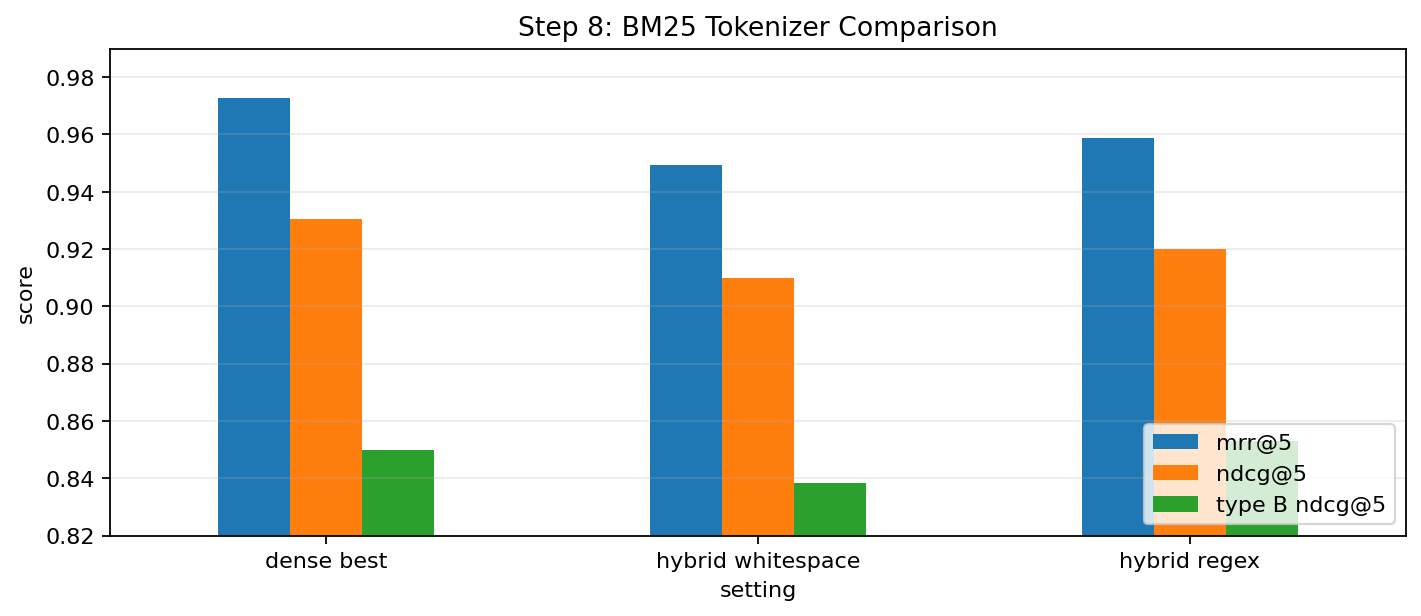

In [29]:
import matplotlib.pyplot as plt

plot_df = bm25_tokenizer_compare.set_index("setting")[["mrr@5", "ndcg@5", "type B ndcg@5"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4), rot=0)
ax.set_title("Step 8: BM25 Tokenizer Comparison")
ax.set_ylim(0.82, 0.99)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 8단계 결론

BM25 tokenizer를 regex 방식으로 바꾸면 hybrid 성능은 개선됐다. `ndcg@5`는 `0.9100`에서 `0.9199`로 올랐고, `mrr@5`도 `0.9493`에서 `0.9587`로 상승했다.

하지만 현재 best인 dense-only `0.9306`에는 아직 못 미친다. 결론적으로 regex BM25는 개선으로 유지할 만하지만, 최종 검색 전략은 여전히 `Dense + doc_id 다양성 + rerank 없음`이 가장 강하다.


# 9단계: doc recall 분석 지표 추가

기존 공식 지표는 `hit@5`, `mrr@5`, `ndcg@5`다. 여기에 분석용 지표를 선택적으로 추가했다. 실행 시 `--include-analysis-metrics`를 붙이면 `eval_results.csv`, `eval_by_type.csv`, `eval_by_difficulty.csv`, `eval_summary.md`에 추가 컬럼이 저장된다.

추가한 지표는 다음과 같다.

- `ground_truth_doc_count`: 질문별 정답 문서 수
- `matched_doc_count`: top-5에서 찾은 정답 문서 수
- `doc_recall_at_5`: 정답 문서 중 top-5에서 찾은 비율
- `multi_doc_recall_at_5`: 정답 문서가 2개 이상인 질문만 대상으로 한 recall
- `all_docs_hit_at_5`: 모든 정답 문서를 top-5 안에서 찾았는지 여부

이 지표는 공식 점수를 대체하는 것이 아니라, 다중 문서 질문에서 왜 nDCG가 낮아지는지 해석하기 위한 보조 지표다.


In [30]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "eval/evaluation/src"))

from rag_eval.aggregation import aggregate_phase1
from rag_eval.loaders import load_eval_csvs, load_predictions_jsonl, merge_eval_predictions
from rag_eval.retrieval_metrics import evaluate_phase1

eval_df = load_eval_csvs(PROJECT_ROOT / "data/eval", canonical_only=True)
experiments = [
    ("dense best", "outputs/predictions/20_dense_diverse100_no_rerank_soyeon_125_koe5_faiss_canonical.jsonl"),
    ("hybrid whitespace", "outputs/predictions/28_hybrid_whitespace_bm25_dense03_diverse100_soyeon_125_koe5_faiss_canonical.jsonl"),
    ("hybrid regex", "outputs/predictions/29_hybrid_regex_bm25_dense03_diverse100_soyeon_125_koe5_faiss_canonical.jsonl"),
]

analysis_rows = []
for label, pred_path in experiments:
    pred_df = load_predictions_jsonl(PROJECT_ROOT / pred_path)
    merged = merge_eval_predictions(eval_df, pred_df)
    phase1 = evaluate_phase1(merged, include_analysis_metrics=True)
    summary, by_type, _ = aggregate_phase1(phase1)
    type_b = by_type[by_type["type"] == "B"].iloc[0]
    analysis_rows.append({
        "setting": label,
        "hit@5": summary["overall_hit_at_5"],
        "ndcg@5": summary["overall_ndcg_at_5"],
        "doc_recall@5": summary["overall_doc_recall_at_5"],
        "multi_doc_recall@5": summary["overall_multi_doc_recall_at_5"],
        "type B multi_doc_recall@5": type_b["multi_doc_recall_at_5"],
    })

analysis_compare = pd.DataFrame(analysis_rows)
analysis_compare_display = analysis_compare.copy()
for col in analysis_compare_display.columns[1:]:
    analysis_compare_display[col] = analysis_compare_display[col].map(lambda v: f"{v:.4f}")
analysis_compare_display


setting,hit@5,ndcg@5,doc_recall@5,multi_doc_recall@5,type B multi_doc_recall@5
dense best,1.0000,0.9306,0.9408,0.8543,0.8546
hybrid whitespace,0.9920,0.9100,0.9273,0.8210,0.8333
hybrid regex,0.9960,0.9199,0.9335,0.8362,0.8462


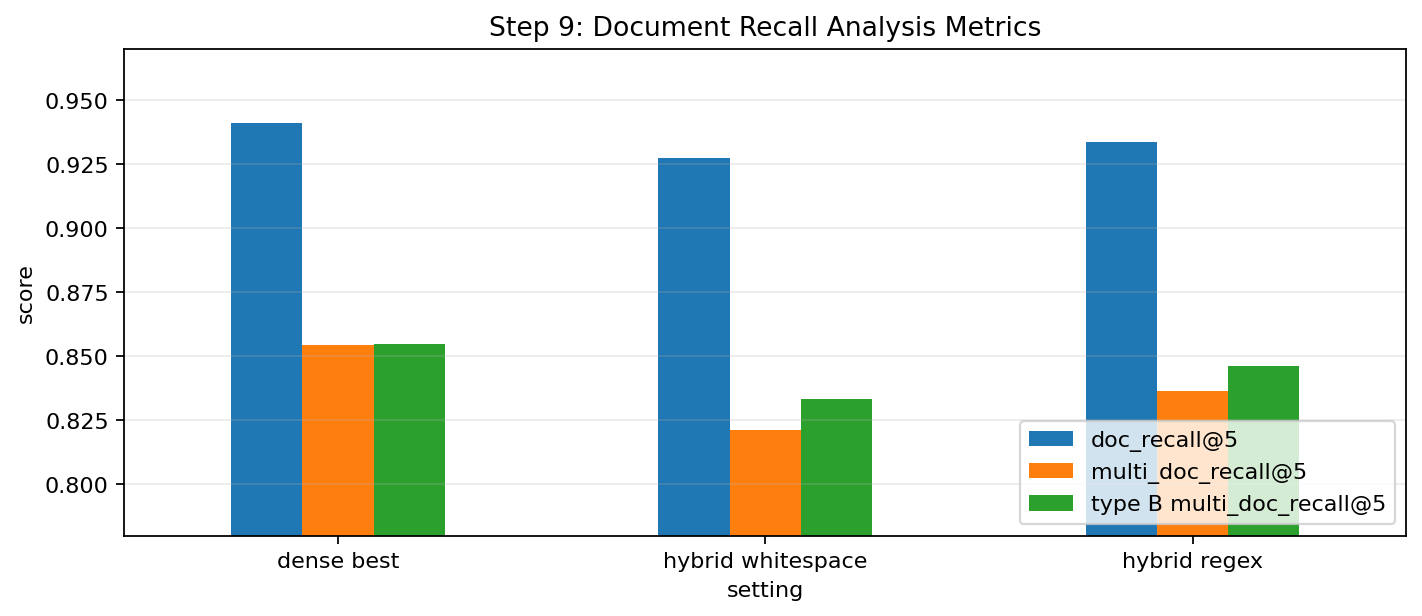

In [31]:
import matplotlib.pyplot as plt

plot_df = analysis_compare.set_index("setting")[["doc_recall@5", "multi_doc_recall@5", "type B multi_doc_recall@5"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4), rot=0)
ax.set_title("Step 9: Document Recall Analysis Metrics")
ax.set_ylim(0.78, 0.97)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 9단계 결론

분석 지표에서도 현재 best인 dense-only가 가장 좋다. `doc_recall@5`는 dense best가 `0.9408`, hybrid regex가 `0.9335`, hybrid whitespace가 `0.9273`였다.

다중 문서 질문만 보는 `multi_doc_recall@5`도 dense best가 `0.8543`로 가장 높다. 이 말은 dense best가 단순히 첫 정답 문서만 잘 찾는 것이 아니라, 여러 정답 문서를 top-5 안에 더 많이 담고 있다는 뜻이다.


# 10단계: 문서 단위 scoring 개선

기존 best는 chunk 검색 결과에서 `doc_id`가 겹치지 않도록 top-5 문서를 고르는 방식이었다. 이 방식은 사실상 각 문서의 최고 점수 chunk 하나를 대표로 보는 것과 가깝다.

이번에는 후보 100개 안에서 같은 문서의 chunk 점수를 모아 문서 점수를 다시 계산했다.

- `max100`: 문서 내 최고 chunk 점수
- `mean_top3`: 문서 내 상위 3개 chunk 평균
- `sum_top3`: 문서 내 상위 3개 chunk 합산

공통 조건은 `Dense + FAISS + KoE5 + rerank 없음`이다.


In [32]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "eval/evaluation/src"))

from rag_eval.aggregation import aggregate_phase1
from rag_eval.loaders import load_eval_csvs, load_predictions_jsonl, merge_eval_predictions
from rag_eval.retrieval_metrics import evaluate_phase1

eval_df = load_eval_csvs(PROJECT_ROOT / "data/eval", canonical_only=True)
experiments = [
    ("dense diversity best", "outputs/predictions/20_dense_diverse100_no_rerank_soyeon_125_koe5_faiss_canonical.jsonl", "0:45"),
    ("docscore max100", "outputs/predictions/33_dense_docscore_max100_soyeon_125_koe5_faiss_canonical.jsonl", "0:48"),
    ("docscore mean_top3", "outputs/predictions/34_dense_docscore_mean_top3_100_soyeon_125_koe5_faiss_canonical.jsonl", "0:46"),
    ("docscore sum_top3", "outputs/predictions/35_dense_docscore_sum_top3_100_soyeon_125_koe5_faiss_canonical.jsonl", "0:46"),
]

docscore_rows = []
for label, pred_path, elapsed in experiments:
    phase1 = evaluate_phase1(
        merge_eval_predictions(eval_df, load_predictions_jsonl(PROJECT_ROOT / pred_path)),
        include_analysis_metrics=True,
    )
    summary, by_type, _ = aggregate_phase1(phase1)
    type_b = by_type[by_type["type"] == "B"].iloc[0]
    docscore_rows.append({
        "setting": label,
        "elapsed": elapsed,
        "hit@5": summary["overall_hit_at_5"],
        "mrr@5": summary["overall_mrr_at_5"],
        "ndcg@5": summary["overall_ndcg_at_5"],
        "doc_recall@5": summary["overall_doc_recall_at_5"],
        "multi_doc_recall@5": summary["overall_multi_doc_recall_at_5"],
        "type B multi_doc_recall@5": type_b["multi_doc_recall_at_5"],
    })

docscore_compare = pd.DataFrame(docscore_rows)
docscore_display = docscore_compare.copy()
for col in docscore_display.columns[2:]:
    docscore_display[col] = docscore_display[col].map(lambda v: f"{v:.4f}")
docscore_display


setting,elapsed,hit@5,mrr@5,ndcg@5,doc_recall@5,multi_doc_recall@5,type B multi_doc_recall@5
dense diversity best,0:45,1.0000,0.9728,0.9306,0.9408,0.8543,0.8546
docscore max100,0:48,1.0000,0.9728,0.9306,0.9408,0.8543,0.8546
docscore mean_top3,0:46,1.0000,0.9608,0.9253,0.9402,0.8526,0.8529
docscore sum_top3,0:46,1.0000,0.9618,0.9274,0.9425,0.8584,0.8562


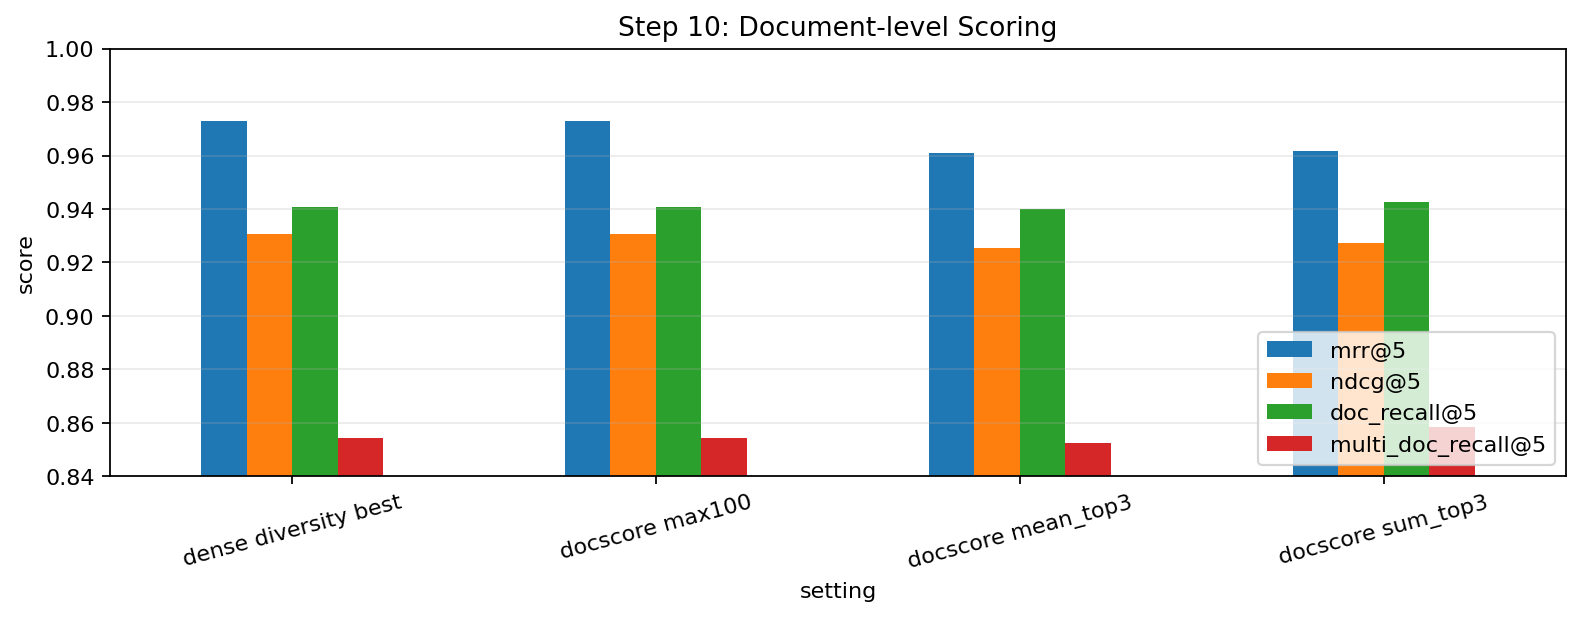

In [33]:
import matplotlib.pyplot as plt

plot_df = docscore_compare.set_index("setting")[["mrr@5", "ndcg@5", "doc_recall@5", "multi_doc_recall@5"]]
ax = plot_df.plot(kind="bar", figsize=(10, 4), rot=15)
ax.set_title("Step 10: Document-level Scoring")
ax.set_ylim(0.84, 1.0)
ax.set_ylabel("score")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 10단계 결론

순위 품질 기준으로는 `dense diversity best`가 가장 좋았다. `max100`은 기존 dense diversity best와 같은 결과라, 현재 diversity 방식이 사실상 최고 chunk 기반 문서 scoring과 동일하게 작동하고 있음을 확인했다.

`sum_top3`는 `doc_recall@5`가 `0.9425`로 가장 높았지만, `ndcg@5`와 `mrr@5`는 best보다 낮았다. 즉 여러 chunk 점수 합산은 더 많은 정답 문서를 담는 데 약간 유리하지만, 순위까지 고려하면 현재 best를 대체할 정도는 아니다.


# 11단계: fetch-k / diversity candidates sweep

현재 best 구조는 dense 검색 후보를 넓게 가져온 뒤, `doc_id` 기준으로 서로 다른 문서를 top-5에 넣는 방식이다. 여기서 `diversity_candidates`는 내부 후보 chunk를 몇 개까지 볼지에 해당한다.

이번 실험은 `Dense + FAISS + KoE5 + rerank 없음 + doc_id diversity`를 유지하고, 후보 수만 `10 / 20 / 50 / 100 / 200`으로 바꿨다.


In [34]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "eval/evaluation/src"))

from rag_eval.aggregation import aggregate_phase1
from rag_eval.loaders import load_eval_csvs, load_predictions_jsonl, merge_eval_predictions
from rag_eval.retrieval_metrics import evaluate_phase1

eval_df = load_eval_csvs(PROJECT_ROOT / "data/eval", canonical_only=True)
experiments = [
    (10, "outputs/predictions/36_dense_diverse10_soyeon_125_koe5_faiss_canonical.jsonl", "0:32"),
    (20, "outputs/predictions/37_dense_diverse20_soyeon_125_koe5_faiss_canonical.jsonl", "0:32"),
    (50, "outputs/predictions/38_dense_diverse50_soyeon_125_koe5_faiss_canonical.jsonl", "0:33"),
    (100, "outputs/predictions/20_dense_diverse100_no_rerank_soyeon_125_koe5_faiss_canonical.jsonl", "0:45"),
    (200, "outputs/predictions/39_dense_diverse200_soyeon_125_koe5_faiss_canonical.jsonl", "1:39"),
]

sweep_rows = []
for candidates, pred_path, elapsed in experiments:
    phase1 = evaluate_phase1(
        merge_eval_predictions(eval_df, load_predictions_jsonl(PROJECT_ROOT / pred_path)),
        include_analysis_metrics=True,
    )
    summary, by_type, _ = aggregate_phase1(phase1)
    type_b = by_type[by_type["type"] == "B"].iloc[0]
    sweep_rows.append({
        "candidates": candidates,
        "elapsed": elapsed,
        "hit@5": summary["overall_hit_at_5"],
        "mrr@5": summary["overall_mrr_at_5"],
        "ndcg@5": summary["overall_ndcg_at_5"],
        "doc_recall@5": summary["overall_doc_recall_at_5"],
        "multi_doc_recall@5": summary["overall_multi_doc_recall_at_5"],
        "type B multi_doc_recall@5": type_b["multi_doc_recall_at_5"],
    })

candidate_sweep = pd.DataFrame(sweep_rows)
candidate_sweep_display = candidate_sweep.copy()
for col in candidate_sweep_display.columns[2:]:
    candidate_sweep_display[col] = candidate_sweep_display[col].map(lambda v: f"{v:.4f}")
candidate_sweep_display


candidates,elapsed,hit@5,mrr@5,ndcg@5,doc_recall@5,multi_doc_recall@5,type B multi_doc_recall@5
10,0:32,1.0000,0.9728,0.9072,0.9038,0.7631,0.7646
20,0:32,1.0000,0.9728,0.9194,0.9230,0.8103,0.8125
50,0:33,1.0000,0.9728,0.9270,0.9348,0.8395,0.8421
100,0:45,1.0000,0.9728,0.9306,0.9408,0.8543,0.8546
200,1:39,1.0000,0.9728,0.9316,0.9425,0.8584,0.8588


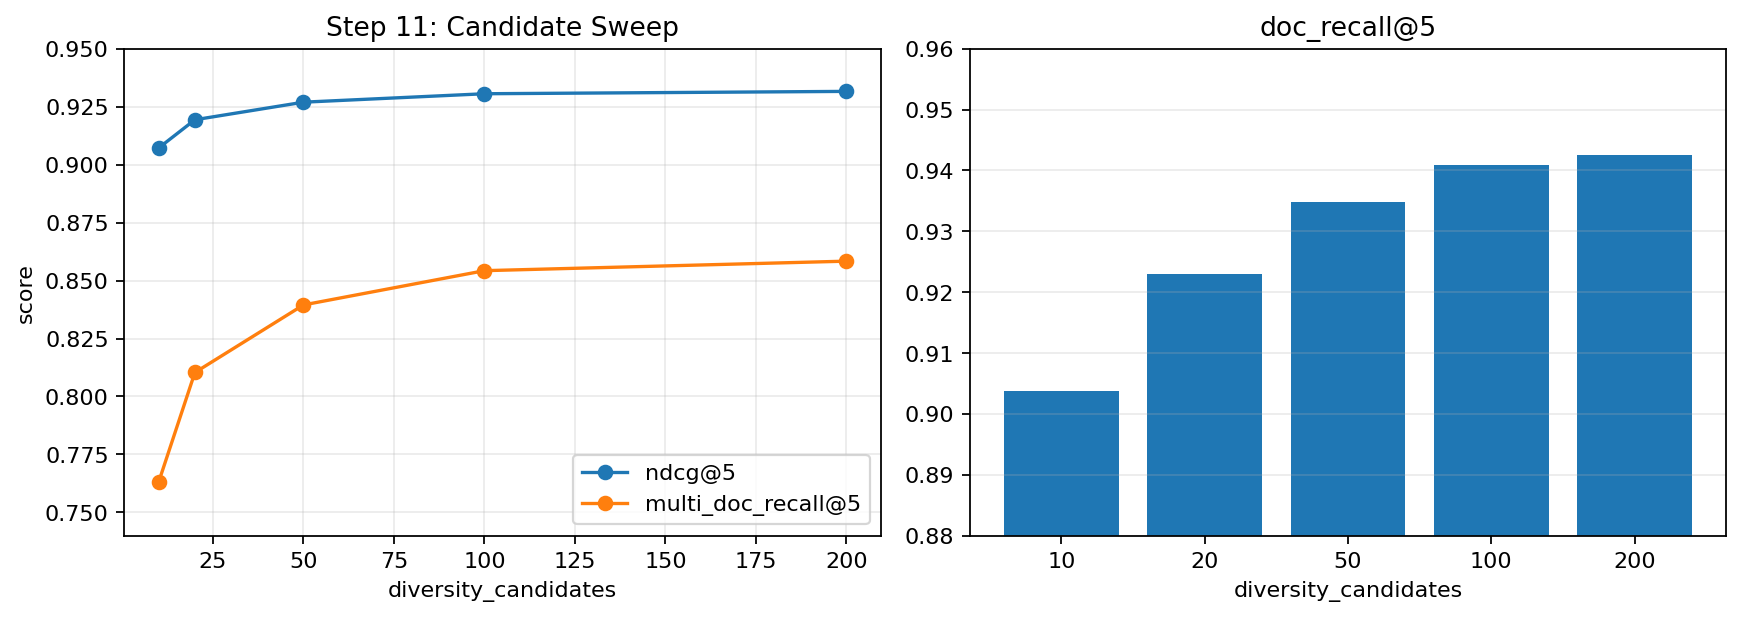

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(candidate_sweep["candidates"], candidate_sweep["ndcg@5"], marker="o", label="ndcg@5")
axes[0].plot(candidate_sweep["candidates"], candidate_sweep["multi_doc_recall@5"], marker="o", label="multi_doc_recall@5")
axes[0].set_title("Step 11: Candidate Sweep")
axes[0].set_xlabel("diversity_candidates")
axes[0].set_ylabel("score")
axes[0].set_ylim(0.74, 0.95)
axes[0].grid(alpha=0.25)
axes[0].legend()
axes[1].bar(candidate_sweep["candidates"].astype(str), candidate_sweep["doc_recall@5"])
axes[1].set_title("doc_recall@5")
axes[1].set_xlabel("diversity_candidates")
axes[1].set_ylim(0.88, 0.96)
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### 11단계 결론

후보 수는 클수록 좋아졌다. `diversity_candidates=200`이 `ndcg@5=0.9316`, `doc_recall@5=0.9425`, `multi_doc_recall@5=0.8584`로 가장 높았다.

`hit@5`와 `mrr@5`는 모든 후보 수에서 동일했지만, 후보 수가 커질수록 여러 정답 문서를 더 많이 담아서 `ndcg@5`와 recall 계열 지표가 개선됐다. 따라서 현재 best 후보 수는 200이다.


# 12단계: 부분 실패 케이스 분석

최종 후보인 `Dense + KoE5 + FAISS + doc_id diversity candidates=200 + rerank 없음` 기준으로 `doc_recall_at_5 < 1`인 질문을 따로 모았다. 여기서 부분 실패는 정답 문서가 여러 개인데 top-5에 일부만 들어온 경우다.

분석 파일은 `eval/evaluation/outputs/eval/partial_failure_dense_diverse200.csv`에 저장했다.


In [36]:
import pandas as pd

partial_path = "../eval/evaluation/outputs/eval/partial_failure_dense_diverse200.csv"
partial = pd.read_csv(partial_path)

summary_rows = [
    {"metric": "partial_failure_count", "value": len(partial)},
    {"metric": "total_questions", "value": 500},
    {"metric": "partial_failure_rate", "value": len(partial) / 500},
]
for type_name, count in partial.groupby("type").size().items():
    summary_rows.append({"metric": f"type_{type_name}_partial_count", "value": int(count)})
for gt_count, count in partial.groupby("ground_truth_doc_count").size().items():
    summary_rows.append({"metric": f"gt_docs_{int(gt_count)}_partial_count", "value": int(count)})

partial_summary = pd.DataFrame(summary_rows)
partial_summary


metric,value
partial_failure_count,61
total_questions,500
partial_failure_rate,0.1220
type_B_partial_count,60
type_E_partial_count,1
gt_docs_2_partial_count,36
gt_docs_3_partial_count,20
gt_docs_4_partial_count,5


In [37]:
top_cases = partial[[
    "id", "type", "difficulty", "ground_truth_doc_count", "matched_doc_count",
    "doc_recall_at_5", "missing_doc_count", "question"
]].head(10).copy()
top_cases["question"] = top_cases["question"].astype(str).str.slice(0, 90) + "..."
top_cases


id,type,difficulty,ground_truth_doc_count,matched_doc_count,doc_recall_at_5,missing_doc_count,question
Q494,B,상,4,1,0.2500,3,"코이카 우즈벡 관개 사업비(50.31억), 서울시 여성가족재단 디지털성범죄 체계(3.36억), 부산국제영화제 예매망(2.43억), 한국연구재단 실태조사망(1.29..."
Q394,B,상,4,2,0.5000,2,"코이카 우즈베키스탄 의정 방송 구축 사업(국제/통신), 케빈랩 AI 영상망(물리/재난), 광주과학기술원 RCMS 연계 변경비(서버/연동), 대한상공회의소 에너지 ..."
Q433,B,상,4,2,0.5000,2,"아시아물위원회사무국 우즈벡 관개 사업비, 부산관광공사 경영정보망 사업비, 광주문화재단 보수 용역비, 남서울대 암호화 용역 예산을 사전 총결산하십시오. 다음으로, ..."
Q453,B,상,4,2,0.5000,2,"코이카-아시아물위원회 우즈벡 관개망, 한국연구재단 실태조사 시스템(1.293억), 부산관광공사 시스템 개선(1.09억), 한국보건산업진흥원 의료기기 시스템(0.5..."
Q474,B,상,4,2,0.5000,2,"코이카 우즈베키스탄 관개망(50.31억), 부산관광공사 경영망(1.09억), (사)부산국제영화제 예매망(2.43억), 남서울대 암호화 행정망(0.70억) 4곳의 ..."
Q034,B,상,3,1,0.3333,2,"코이카의 '우즈베키스탄 방송시스템 사업', 아시아물위원회의 '우즈벡-키르기즈스탄 관개시스템 사업', 수출입은행의 '모잠비크 ITS 타당성 조사 사업'은 모두 중앙..."
Q148,B,하,3,1,0.3333,2,"경희대학교 산학협력단 시스템 운영, 철도공사 모바일오피스 고도화, (주)에스알 예약발매 ISMP 사업 중 단독 예산액이 명시된 사업이 존재합니까?..."
Q274,B,상,3,1,0.3333,2,"본 섹션에 명시된 고려대학교 학사 정보 차세대 사업, 수자원공사 건설통합시스템 확충 사업, 보건산업진흥원 의료기기시스템 기능개선의 배정 예산을 우선 일괄 병합 계..."
Q388,B,하,3,1,0.3333,2,"대한상공회의소 에너지 개편 비용, 을지대 비교과시스템 확충 비용, 시립대 종단분석 통합망 총괄 비용, 이들 세 곳 중에서 가장 든든한 예산 액수가 문건 내에 명시..."
Q013,B,상,3,2,0.6667,1,"고려대학교의 '차세대 포털·학사 정보시스템', 그랜드코리아레저(주)의 '그룹웨어 시스템', 인천광역시의 '통합관리시스템 구축' 세 기관의 정보화 구축 사업에서 각..."


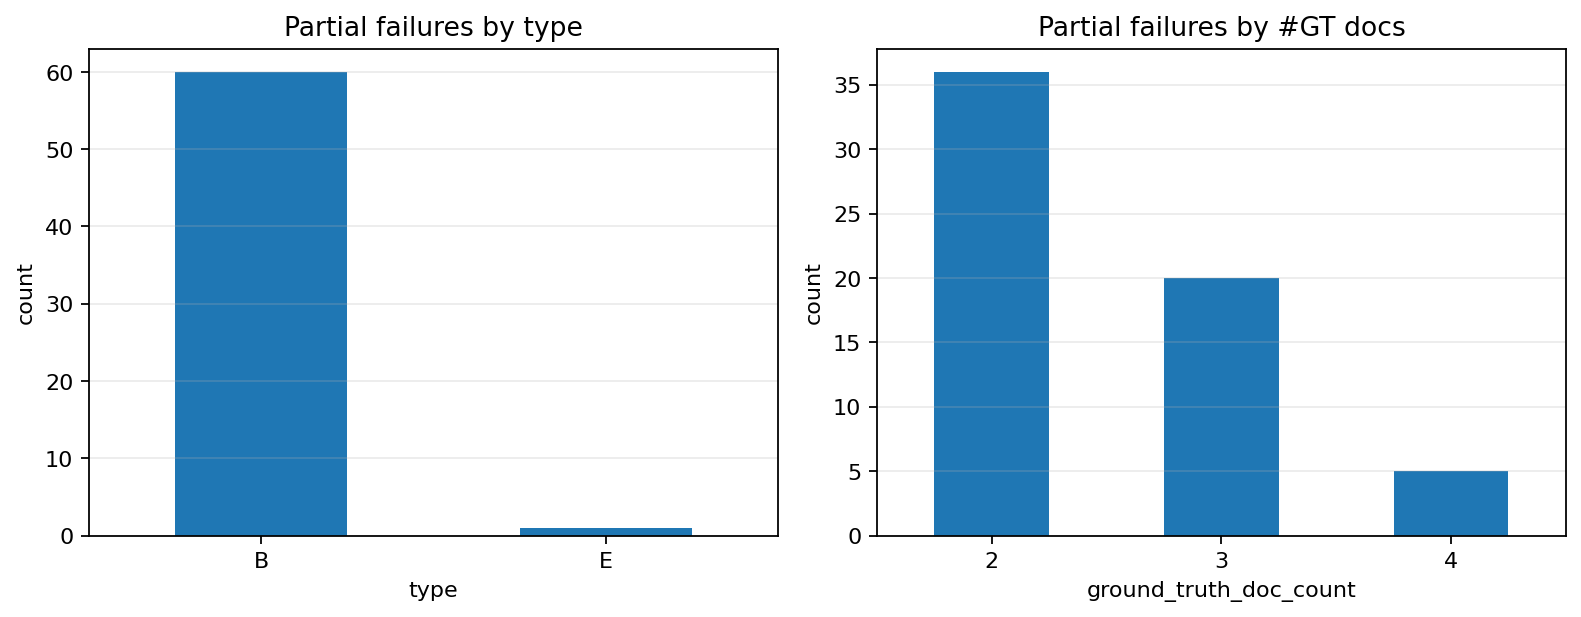

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
partial.groupby("type").size().plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Partial failures by type")
axes[0].set_ylabel("count")
axes[0].grid(axis="y", alpha=0.25)
partial.groupby("ground_truth_doc_count").size().plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Partial failures by #GT docs")
axes[1].set_xlabel("ground_truth_doc_count")
axes[1].set_ylabel("count")
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### 12단계 결론

남은 부분 실패 61건 중 60건이 type B이고, 대부분 정답 문서가 2개 이상인 질문이다. 특히 정답 문서가 3~4개인 질문에서는 top-5 안에 모든 정답 문서를 넣기 어렵다.

대표 실패 사례를 보면 질문 안에 여러 기관/사업명이 동시에 들어가는데, 검색은 질문 전체를 하나의 query로 보고 수행한다. 그래서 질문에서 강하게 드러나는 한두 사업 쪽 문서가 top-5를 차지하고, 상대적으로 약하게 언급된 사업 문서가 밀린다.

따라서 다음 개선 후보는 단순 rerank보다 `질문 분해`다. 예를 들어 질문 안의 사업명/기관명/예산 단서를 여러 sub-query로 나누고, sub-query별 검색 결과를 합쳐서 문서 다양성을 적용하는 방식이 더 맞아 보인다.


# 13단계: Query decomposition 실험

12단계에서 남은 부분 실패가 type B 다중 문서 질문에 몰려 있다는 것을 확인했다. 그래서 질문 하나를 그대로 검색하지 않고, 질문 안의 기관명/사업명/예산 단서를 여러 sub-query로 나눈 뒤 결과를 합치는 방식을 실험했다.

실험 기준은 기존 best와 동일하게 `soyeon 125 chunks_v2`, `KoE5`, `FAISS`, canonical 500문항이다. 단, query decomposition 실험에서는 sub-query별 후보를 모은 뒤 `round_robin` 또는 `RRF`로 문서 단위 결과를 합쳤다.


In [ ]:
import pandas as pd

qdecomp_path = "../eval/evaluation/outputs/eval/query_decomposition_experiment_summary.csv"
qdecomp_summary = pd.read_csv(qdecomp_path)

score_cols = [
    "setting", "hit@5", "mrr@5", "ndcg@5",
    "doc_recall@5", "multi_doc_recall@5",
    "typeB_multi_doc_recall@5", "typeB_ndcg@5", "all_docs_hit@5",
]
qdecomp_summary[score_cols]


In [ ]:
import matplotlib.pyplot as plt

plot_df = qdecomp_summary.set_index("setting")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_df[["hit@5", "mrr@5", "ndcg@5"]].plot(kind="bar", ax=axes[0], rot=45)
axes[0].set_title("Step 13: Official retrieval metrics")
axes[0].set_ylim(0.88, 1.01)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(loc="lower left")

plot_df[["multi_doc_recall@5", "typeB_multi_doc_recall@5", "all_docs_hit@5"]].plot(kind="bar", ax=axes[1], rot=45)
axes[1].set_title("Step 13: Multi-document coverage")
axes[1].set_ylim(0.82, 0.97)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


### 13단계 결론

Query decomposition은 목적에 따라 평가가 갈렸다. 공식 검색 지표 기준 최고는 여전히 `39 best dense diverse200`이다. 이 조합은 `hit@5=1.0000`, `mrr@5=0.9728`, `ndcg@5=0.9316`으로 가장 안정적이었다.

반면 여러 정답 문서를 모두 회수하는 능력은 `43 qdecomp relaxed RRF k100`이 가장 좋았다. `multi_doc_recall@5`가 `0.8584 -> 0.9433`, type B `multi_doc_recall@5`가 `0.8588 -> 0.9425`, `all_docs_hit@5`가 `0.8780 -> 0.9280`으로 올랐다. 즉 다중 문서 질문에서 더 많은 정답 문서를 담는 데는 효과가 있었다.

다만 relaxed 방식은 metadata filter를 무시하기 때문에 단일 정답을 정확히 top rank에 놓는 능력은 떨어졌다. 그래서 전체 `hit@5`, `mrr@5`, `ndcg@5`는 best보다 낮았다. 현재 최종 조합에는 query decomposition을 기본값으로 넣기보다, 다중 문서 질문이 강하게 의심되는 경우에만 선택적으로 쓰는 후보로 남기는 것이 좋아 보인다.


# 14단계: Conditional query decomposition

13단계의 query decomposition은 다중 문서 회수율은 올렸지만, 모든 질문에 적용하면 단일 문서 질문의 순위 안정성이 떨어질 수 있었다. 그래서 이번 단계에서는 질문이 실제로 여러 기관/사업/예산 단서로 분해될 때만 query decomposition을 적용했다.

또한 `사업`처럼 너무 넓은 단어만으로는 list item으로 보지 않도록 보정했다. 이 보정 후 Q035 같은 일반 쉼표 문장은 분해하지 않고, Q494 같은 다중 사업/예산 질문은 4개 sub-query로 분해된다.


In [ ]:
import pandas as pd

conditional_path = "../eval/evaluation/outputs/eval/conditional_query_decomposition_experiment_summary.csv"
conditional_summary = pd.read_csv(conditional_path)

score_cols = [
    "setting", "hit@5", "mrr@5", "ndcg@5",
    "doc_recall@5", "multi_doc_recall@5",
    "typeB_multi_doc_recall@5", "typeB_ndcg@5",
    "all_docs_hit@5", "applied_questions", "hit_misses",
]
conditional_summary[score_cols]


In [ ]:
import matplotlib.pyplot as plt

plot_df = conditional_summary.set_index("setting")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_df[["hit@5", "mrr@5", "ndcg@5"]].plot(kind="bar", ax=axes[0], rot=35)
axes[0].set_title("Step 14: Official retrieval metrics")
axes[0].set_ylim(0.92, 1.01)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(loc="lower left")

plot_df[["multi_doc_recall@5", "typeB_multi_doc_recall@5", "all_docs_hit@5"]].plot(kind="bar", ax=axes[1], rot=35)
axes[1].set_title("Step 14: Multi-document coverage")
axes[1].set_ylim(0.84, 0.94)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


### 14단계 결론

`48 conditional qdecomp filter RRF k100`은 기존 best보다 공식 지표가 모두 좋아진 안정형 개선이다. `hit@5=1.0000`, `mrr@5=0.9738`, `ndcg@5=0.9367`로 기존 `39`의 `1.0000 / 0.9728 / 0.9316`을 모두 넘었다.

`50 conditional qdecomp multi relaxed filter kept`는 전체적으로 가장 설득력 있는 성능 향상 후보이다. `hit@5=1.0000`을 유지하면서 `ndcg@5=0.9478`, `multi_doc_recall@5=0.9195`, type B `multi_doc_recall@5=0.9208`까지 올라갔다. 단, `mrr@5=0.9690`으로 기존 best보다 아주 조금 낮다.

현재 최종 후보는 두 개로 정리할 수 있다. 보수적으로는 `48`, 다중 문서 문제까지 더 잘 풀고 싶다면 `50`이다. 이 프로젝트의 남은 약점이 type B 다중 문서 회수율이었기 때문에, 실전 기본값으로는 `50`을 우선 추천한다.


# 최종 정리: 현재 best 조합과 다음 후보

## 현재 추천 조합

현재 canonical 500문항 기준 가장 추천하는 조합은 `51 conditional qdecomp multi relaxed filter kept + diversity candidates 100`이다. 기존 `50`과 점수는 같고, prediction 생성 시간이 더 짧다.

```bash
.venv/bin/python scripts/generate_eval_predictions.py \
  --retriever dense \
  --chunks /home/codeit/shared_file/dataset/soyeon/125_260520/chunks_v2_125.jsonl \
  --embedding-preset koe5 \
  --index-dir indexes/faiss_koe5_soyeon_125_260520_chunks_v2_125 \
  --query-decomposition \
  --decomposition-conditional \
  --decomposition-candidates-per-query 100 \
  --decomposition-max-queries 8 \
  --decomposition-selection rrf \
  --document-diversity \
  --diversity-candidates 100 \
  --diversity-key doc_id \
  --no-expand-multi-agency-filter \
  --canonical-only \
  --output outputs/predictions/51_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per100_diverse100_soyeon_125_koe5_faiss_canonical.jsonl
```

평가:

```bash
.venv/bin/python eval/scripts/run_evaluation.py \
  --predictions outputs/predictions/51_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per100_diverse100_soyeon_125_koe5_faiss_canonical.jsonl \
  --canonical-only \
  --include-analysis-metrics \
  --experiment-name 51_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per100_diverse100_soyeon_125_koe5_faiss_canonical
```

## 최종 점수

- `hit@5`: 1.0000
- `mrr@5`: 0.9690
- `ndcg@5`: 0.9478
- `doc_recall@5`: 0.9673
- `multi_doc_recall@5`: 0.9195
- type B `multi_doc_recall@5`: 0.9208
- `all_docs_hit@5`: 0.9200
- prediction 생성 시간: `0:57.46`

## 보수적인 대안

공식 지표 3개 모두에서 기존 best를 넘기는 가장 안전한 조합은 `48 conditional qdecomp filter RRF k100`이다.

- `hit@5`: 1.0000
- `mrr@5`: 0.9738
- `ndcg@5`: 0.9367
- `multi_doc_recall@5`: 0.8670

`48`은 안정형, `51`은 다중 문서 회수율과 속도까지 같이 잡은 현재 추천 조합이다. 다음 실험의 기준선은 `51`로 두는 것이 좋다.

## 더 해볼 만한 다음 후보

이제 큰 구조 개선은 꽤 했고, 남은 후보는 세밀한 튜닝이다.

- `decomposition-candidates-per-query`: 50, 100, 150 비교
- `decomposition-min-subqueries`: 2, 3 비교
- 최종 생성 답변까지 붙였을 때 context가 너무 길어지지 않는지 확인
- 새 데이터베이스나 다른 chunk 버전에 `51` 조합을 그대로 적용해서 재현성 확인


# 15단계: Diversity candidates 100 vs 200

현재 1등 조합인 `50`은 `diversity_candidates=200`으로 고유 문서 후보를 구성했다. 시간이 더 줄어드는지 확인하기 위해 나머지 조건은 그대로 두고 `diversity_candidates`만 `100`으로 낮춘 `51` 실험을 추가했다.

비교 기준은 동일하게 canonical 500문항, `KoE5 + FAISS + conditional query decomposition + RRF + no multi-agency expansion`이다.


In [ ]:
import pandas as pd

diversity_compare_path = "../eval/evaluation/outputs/eval/diversity100_vs_200_best_setting_summary.csv"
diversity_compare = pd.read_csv(diversity_compare_path)

diversity_compare[[
    "setting", "hit@5", "mrr@5", "ndcg@5",
    "doc_recall@5", "multi_doc_recall@5", "typeB_multi_doc_recall@5",
    "elapsed", "elapsed_seconds"
]]


In [ ]:
import matplotlib.pyplot as plt

plot_df = diversity_compare.set_index("setting")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [2, 1]})
plot_df[["hit@5", "mrr@5", "ndcg@5", "multi_doc_recall@5"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Score: candidates 200 vs 100")
axes[0].set_ylim(0.90, 1.01)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(loc="lower left")

plot_df["elapsed_seconds"].plot(kind="bar", ax=axes[1], rot=0, color="#6b7280")
axes[1].set_title("Prediction Time")
axes[1].set_ylabel("seconds")
axes[1].grid(axis="y", alpha=0.25)
for container in axes[1].containers:
    axes[1].bar_label(container, labels=plot_df["elapsed"].tolist(), fontsize=9, padding=2)

plt.tight_layout()
plt.show()


### 15단계 결론

`diversity_candidates=100`으로 줄여도 점수는 `50`과 완전히 같았다.

- `hit@5`: 1.0000 유지
- `mrr@5`: 0.9690 유지
- `ndcg@5`: 0.9478 유지
- `multi_doc_recall@5`: 0.9195 유지
- type B `multi_doc_recall@5`: 0.9208 유지

반면 prediction 생성 시간은 `1:31.87 -> 0:57.46`으로 줄었다. 약 37% 빠르다. 따라서 새 추천 기본값은 `50`이 아니라 `51`, 즉 `diversity_candidates=100` 조합이다.


# 전체 실험 조합 랭킹

지금까지 `phase1_retrieval_experiments.csv`에 기록된 실험 조합을 `overall_ndcg_at_5` 기준으로 정렬했다. 같은 `experiment_name`이 여러 번 기록된 경우에는 가장 최근 실행 결과만 사용했다.

정리 파일: `eval/evaluation/outputs/eval/overall_experiment_ranking_by_ndcg.csv`


In [9]:
import pandas as pd

ranking_path = "../eval/evaluation/outputs/eval/overall_experiment_ranking_by_ndcg.csv"
ranking = pd.read_csv(ranking_path)

ranking_view = ranking[[
    "rank", "experiment_name", "retriever_type", "embedding_model", "reranker",
    "overall_hit_at_5", "overall_mrr_at_5", "overall_ndcg_at_5",
    "elapsed", "type_b_ndcg_at_5", "notes"
]].copy()

ranking_view


,rank,experiment_name,retriever_type,embedding_model,reranker,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5,elapsed,type_b_ndcg_at_5,notes
0,1,50_dense_conditional_qdecomp_v2_rrf_multi_rela...,dense,nlpai-lab/KoE5,False,1.000,0.969000,0.947846,1:31.87,0.889213,step14_conditional_query_decomposition_v2_mult...
1,2,49_dense_conditional_qdecomp_v2_rrf_relaxed_pe...,dense,nlpai-lab/KoE5,False,1.000,0.966000,0.945631,1:20.69,0.889213,step14_conditional_query_decomposition_v2_rela...
2,3,47_dense_conditional_qdecomp_rrf_relaxed_per10...,dense,nlpai-lab/KoE5,False,0.998,0.954333,0.939300,1:14.21,0.892612,step14_conditional_query_decomposition_relaxed...
3,4,48_dense_conditional_qdecomp_v2_rrf_filter_per...,dense,nlpai-lab/KoE5,False,1.000,0.973833,0.936686,1:45.94,0.861313,step14_conditional_query_decomposition_v2_filt...
4,5,46_dense_conditional_qdecomp_rrf_filter_per100...,dense,nlpai-lab/KoE5,False,1.000,0.970167,0.935525,2:00.31,0.863293,step14_conditional_query_decomposition_filter_...
5,6,39_dense_diverse200_soyeon_125_koe5_faiss_cano...,dense,nlpai-lab/KoE5,False,1.000,0.972833,0.931612,NaN,0.852318,step11_diversity_candidates_200
6,7,22_dense_diverse100_no_rerank_docnorm_soyeon_1...,dense,nlpai-lab/KoE5,False,1.000,0.972833,0.930594,NaN,0.849775,doc_name_normalization_strict_fuzzy_threshold_098
7,8,30_analysis_dense_best_doc_recall_soyeon_125_k...,dense,nlpai-lab/KoE5,False,1.000,0.972833,0.930594,NaN,0.849775,step9_analysis_metrics_dense_best
8,9,33_dense_docscore_max100_soyeon_125_koe5_faiss...,dense,nlpai-lab/KoE5,False,1.000,0.972833,0.930594,NaN,0.849775,step10_doc_score_max100
9,10,20_dense_diverse100_no_rerank_soyeon_125_koe5_...,dense,nlpai-lab/KoE5,False,0.998,0.970833,0.928594,NaN,0.849775,NaN


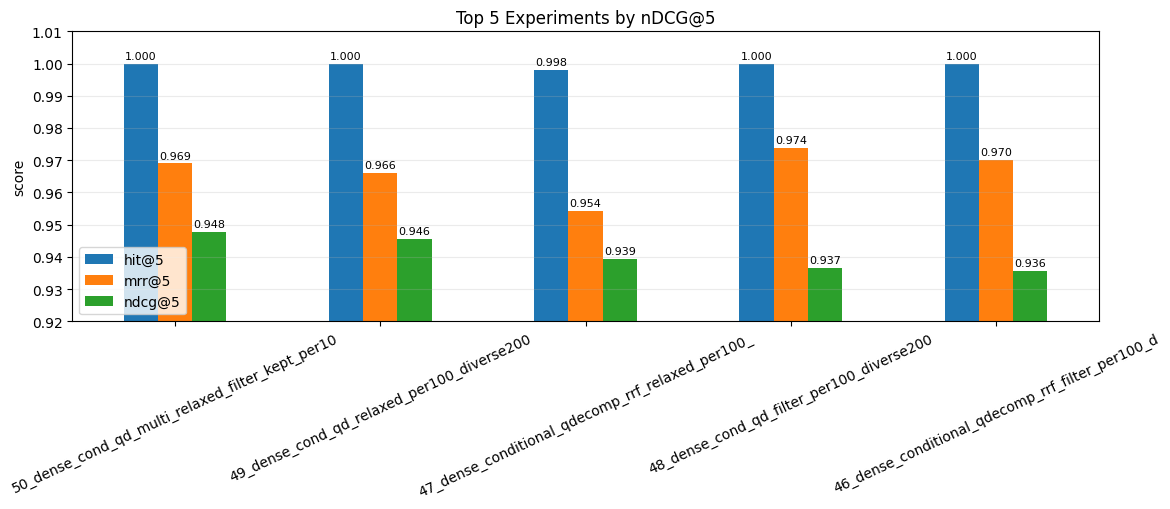

In [8]:
import matplotlib.pyplot as plt


def _fmt_elapsed(seconds):
    if pd.isna(seconds):
        return ""
    minutes = int(seconds // 60)
    rest = seconds - minutes * 60
    return f"{minutes}:{rest:05.2f}"


top5 = ranking.head(5).copy()
top5["label"] = (
    top5["experiment_name"]
    .str.replace("_soyeon_125_koe5_faiss_canonical", "", regex=False)
    .str.replace("_conditional_qdecomp_v2_rrf_", "_cond_qd_", regex=False)
    .str.slice(0, 48)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [2.4, 1]})

score_df = top5.set_index("label")[[
    "overall_hit_at_5", "overall_mrr_at_5", "overall_ndcg_at_5"
]]
score_df.plot(kind="bar", ax=axes[0], rot=25)
axes[0].set_title("Top 5 Experiments by nDCG@5")
axes[0].set_xlabel("")
axes[0].set_ylabel("score")
axes[0].set_ylim(0.92, 1.01)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(["hit@5", "mrr@5", "ndcg@5"], loc="lower left")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=8, padding=2)

elapsed_df = top5.set_index("label")["elapsed_seconds"]
elapsed_df.plot(kind="bar", ax=axes[1], rot=25, color="#6b7280")
axes[1].set_title("Prediction Time")
axes[1].set_xlabel("")
axes[1].set_ylabel("seconds")
axes[1].grid(axis="y", alpha=0.25)
for container in axes[1].containers:
    axes[1].bar_label(container, labels=[_fmt_elapsed(v) for v in elapsed_df.values], fontsize=8, padding=2)

plt.tight_layout()
plt.show()


### 랭킹 요약

상위 5개는 모두 conditional query decomposition 계열이었다. 가장 높은 `ndcg@5`는 `51 conditional qdecomp multi relaxed filter kept + diversity candidates 100` 조합으로, `hit@5=1.0000`, `mrr@5=0.9690`, `ndcg@5=0.9478`이다.

Top 5의 prediction 생성 시간도 함께 표시했다. 현재 1위인 `51`은 약 `0:57.46`이 걸렸고, 기존 1위였던 `50`은 같은 점수지만 `1:31.87`이 걸렸다. 시간은 `/usr/bin/time`으로 기록된 prediction 생성 시간 기준이며, 오래된 일부 실험은 시간이 비어 있을 수 있다.

기존 best였던 `39 dense diverse200`은 `ndcg@5=0.9316`으로 7위가 되었고, conditional routing과 후보 수 축소를 적용한 뒤 새 best가 `51`로 바뀐 상태다.
